In [1]:
from pathlib import Path
import numpy as np
import json
import pickle

# Dataset location
DATA_DIR = Path(".")

print("Current folder:", DATA_DIR.resolve())

print("\nFiles available:")
for file in sorted(DATA_DIR.iterdir()):
    if file.is_file():
        print(f"{file.name:30} {file.stat().st_size / 1024:.2f} KB")

Current folder: C:\Users\gur83\SIH

Files available:
adjacency_matrix_800.npy       5000.12 KB
bengaluru_800.graphml          673.27 KB
bengaluru_800.json             230.92 KB
bengaluru_800.pkl              246.81 KB
edge_list_800.npy              49.62 KB
M1_QPSO_Bengaluru_Data_Inspection.ipynb 0.61 KB
node_coords_800.npy            12.62 KB
node_index_map.json            31.02 KB


In [2]:
# Check the main dataset files

# 1. Node coordinates
node_coords = np.load("node_coords_800.npy", allow_pickle=True)

print("NODE COORDINATES")
print("Shape:", node_coords.shape)
print("Data type:", node_coords.dtype)
print("First 5 entries:")
print(node_coords[:5])


# 2. Edge list
edge_list = np.load("edge_list_800.npy", allow_pickle=True)

print("\nEDGE LIST")
print("Shape:", edge_list.shape)
print("Data type:", edge_list.dtype)
print("First 10 entries:")
print(edge_list[:10])


# 3. Adjacency matrix
adj_matrix = np.load("adjacency_matrix_800.npy", allow_pickle=True)

print("\nADJACENCY MATRIX")
print("Shape:", adj_matrix.shape)
print("Data type:", adj_matrix.dtype)
print("Top-left 5x5:")
print(adj_matrix[:5, :5])

NODE COORDINATES
Shape: (800, 2)
Data type: float64
First 5 entries:
[[12.9592706 77.6028805]
 [12.9692295 77.6063626]
 [12.9682055 77.606431 ]
 [12.9580165 77.606006 ]
 [12.966655  77.6087179]]

EDGE LIST
Shape: (1056, 6)
Data type: float64
First 10 entries:
[[  0.    20.     4.89  38.41  28.3    1.  ]
 [  1.   210.     4.86  54.43  40.3    1.  ]
 [  1.   656.     4.14  33.73  29.3    1.  ]
 [  1.   640.     4.76  53.29  40.3    1.  ]
 [  2.   216.     4.46  24.8   20.     1.  ]
 [  2.   274.     2.33  18.29  28.3    1.  ]
 [  2.   224.     6.22  34.54  20.     1.  ]
 [  3.   720.    22.19 184.94  30.     1.  ]
 [  3.   486.     7.36  80.69  39.5    1.  ]
 [  3.   621.    77.92 649.36  30.     1.  ]]

ADJACENCY MATRIX
Shape: (800, 800)
Data type: float64
Top-left 5x5:
[[ 0. inf inf inf inf]
 [inf  0. inf inf inf]
 [inf inf  0. inf inf]
 [inf inf inf  0. inf]
 [inf inf inf inf  0.]]


In [3]:
# Inspect the JSON mapping

with open("node_index_map.json", "r") as f:
    node_index_map = json.load(f)

print("NODE INDEX MAP")
print("Type:", type(node_index_map))
print("Number of entries:", len(node_index_map))

print("\nFirst 10 entries:")
for i, (key, value) in enumerate(node_index_map.items()):
    print(key, "->", value)
    if i == 9:
        break

NODE INDEX MAP
Type: <class 'dict'>
Number of entries: 2

First 10 entries:
index_to_node -> {'0': '11387494406', '1': '1833752585', '2': '1833752587', '3': '12864985109', '4': '11919132703', '5': '443252777', '6': '443252782', '7': '11356383282', '8': '11356383283', '9': '6458368052', '10': '308924469', '11': '443252791', '12': '308924471', '13': '10060517433', '14': '7088793659', '15': '7088793663', '16': '7088793664', '17': '7088793665', '18': '248455233', '19': '248455237', '20': '248455238', '21': '443252806', '22': '248455241', '23': '443252810', '24': '12508627019', '25': '1232963659', '26': '9981910292', '27': '443252817', '28': '443252820', '29': '10020632663', '30': '10020632664', '31': '443252823', '32': '248455257', '33': '443252829', '34': '443252831', '35': '443252835', '36': '11017150565', '37': '6504235112', '38': '11017150568', '39': '6504235114', '40': '443252841', '41': '443252844', '42': '443252847', '43': '2228056176', '44': '443252850', '45': '2228056179', '46': '

In [4]:
with open("bengaluru_800.pkl", "rb") as f:
    dataset_pkl = pickle.load(f)

print("PKL DATA")
print("Type:", type(dataset_pkl))

if isinstance(dataset_pkl, dict):
    print("Keys:", dataset_pkl.keys())
else:
    print(dataset_pkl)

PKL DATA
Type: <class 'networkx.classes.multigraph.MultiGraph'>
MultiGraph with 800 nodes and 1056 edges


In [5]:
import networkx as nx
import json
import numpy as np

# ---------------------------------------------------------
# STEP 2: Inspect the actual graph structure and attributes
# ---------------------------------------------------------

# Load the NetworkX graph
G = nx.read_graphml("bengaluru_800.graphml")

print("GRAPH INFORMATION")
print("-" * 60)
print("Graph type:", type(G))
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed:", G.is_directed())
print("Is multigraph:", G.is_multigraph())


# ---------------------------------------------------------
# Inspect one node
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SAMPLE NODE")
print("=" * 60)

sample_node = next(iter(G.nodes))

print("Node ID:", sample_node)
print("Node attributes:")
print(G.nodes[sample_node])


# ---------------------------------------------------------
# Inspect first few edges
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SAMPLE EDGES")
print("=" * 60)

for i, edge in enumerate(G.edges(data=True, keys=True)):
    print(edge)

    if i >= 9:
        break


# ---------------------------------------------------------
# Inspect graph-level attributes
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("GRAPH ATTRIBUTES")
print("=" * 60)

print(G.graph)


# ---------------------------------------------------------
# Inspect JSON file
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("BENGALURU JSON")
print("=" * 60)

with open("bengaluru_800.json", "r") as f:
    data_json = json.load(f)

print("JSON type:", type(data_json))

if isinstance(data_json, dict):
    print("JSON keys:")
    for key in data_json.keys():
        print(" -", key)

else:
    print(data_json)


# ---------------------------------------------------------
# Inspect finite values in adjacency matrix
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("ADJACENCY MATRIX CHECK")
print("=" * 60)

finite_values = adj_matrix[np.isfinite(adj_matrix)]

print("Total matrix entries:", adj_matrix.size)
print("Finite entries:", len(finite_values))
print("Infinite entries:", np.isinf(adj_matrix).sum())

if len(finite_values) > 0:
    print("Minimum finite value:", finite_values.min())
    print("Maximum finite value:", finite_values.max())

GRAPH INFORMATION
------------------------------------------------------------
Graph type: <class 'networkx.classes.multigraph.MultiGraph'>
Number of nodes: 800
Number of edges: 1056
Is directed: False
Is multigraph: True

SAMPLE NODE
Node ID: 11387494406
Node attributes:
{'y': '12.9592706', 'x': '77.6028805', 'street_count': '1'}

SAMPLE EDGES
('11387494406', '248455238', 0, {'osmid': '1227997925', 'highway': 'residential', 'name': '1st Cross Road', 'oneway': 'False', 'reversed': 'True', 'length': '38.41449566495511', 'geometry': 'LINESTRING (77.6028805 12.9592706, 77.602986 12.9595612, 77.6029987 12.9595963)', 'speed_kph': '28.295270690728064', 'travel_time': '4.887466386358151', 'traffic_factor': '1.0', 'effective_weight': '4.887466386358151'})
('1833752585', '442972782', 0, {'osmid': '23029284', 'highway': 'secondary', 'lanes': '3', 'name': 'Brigade Road', 'oneway': 'True', 'reversed': 'False', 'length': '54.42539615622363', 'speed_kph': '40.28232087227414', 'travel_time': '4.86395

In [6]:
# ============================================================
# STEP 3: Inspect VRP-related information
# ============================================================

import json
import pprint

# ------------------------------------------------------------
# Inspect the JSON structure
# ------------------------------------------------------------

with open("bengaluru_800.json", "r") as f:
    data = json.load(f)

print("=" * 70)
print("JSON STRUCTURE")
print("=" * 70)

print("Top-level keys:")
print(list(data.keys()))


# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("METADATA")
print("=" * 70)

metadata = data.get("metadata", {})

print("Type:", type(metadata))
pprint.pp(metadata)


# ------------------------------------------------------------
# Nodes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("JSON NODES")
print("=" * 70)

nodes = data.get("nodes", [])

print("Type:", type(nodes))
print("Number of nodes:", len(nodes))

if isinstance(nodes, list) and len(nodes) > 0:
    print("\nFirst node:")
    pprint.pp(nodes[0])

elif isinstance(nodes, dict):
    print("\nNumber of node entries:", len(nodes))

    first_key = next(iter(nodes))
    print("\nFirst node:")
    print("Node ID:", first_key)
    pprint.pp(nodes[first_key])


# ------------------------------------------------------------
# Edges
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("JSON EDGES")
print("=" * 70)

edges = data.get("edges", [])

print("Type:", type(edges))
print("Number of edges:", len(edges))

if isinstance(edges, list) and len(edges) > 0:
    print("\nFirst edge:")
    pprint.pp(edges[0])

elif isinstance(edges, dict):
    print("\nNumber of edge entries:", len(edges))

    first_key = next(iter(edges))
    print("\nFirst edge:")
    print("Edge ID:", first_key)
    pprint.pp(edges[first_key])

JSON STRUCTURE
Top-level keys:
['metadata', 'nodes', 'edges']

METADATA
Type: <class 'dict'>
{'city': 'Bengaluru',
 'nodes': 800,
 'edges': 1056,
 'network_type': 'drive',
 'crs': 'EPSG:4326'}

JSON NODES
Type: <class 'list'>
Number of nodes: 800

First node:
{'id': '11387494406', 'lat': 12.959271, 'lon': 77.60288, 'street_count': 1}

JSON EDGES
Type: <class 'list'>
Number of edges: 1056

First edge:
{'u': '11387494406',
 'v': '248455238',
 'length': 38.41,
 'speed_kph': 28.3,
 'travel_time': 4.89,
 'traffic_factor': 1.0,
 'effective_weight': 4.89,
 'name': '1st Cross Road'}


In [7]:
# ============================================================
# STEP 4: Validate the Bengaluru road network
# ============================================================

import networkx as nx
import numpy as np

print("=" * 70)
print("GRAPH CONNECTIVITY")
print("=" * 70)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Check connected components
components = list(nx.connected_components(G))

print("Number of connected components:", len(components))

component_sizes = sorted(
    [len(component) for component in components],
    reverse=True
)

print("Largest component size:", component_sizes[0])

if len(component_sizes) > 1:
    print("Other component sizes:", component_sizes[1:])
else:
    print("All 800 nodes belong to one connected component.")


# ============================================================
# Check isolated nodes
# ============================================================

print("\n" + "=" * 70)
print("ISOLATED NODES")
print("=" * 70)

isolated_nodes = list(nx.isolates(G))

print("Number of isolated nodes:", len(isolated_nodes))

if isolated_nodes:
    print("First isolated nodes:", isolated_nodes[:20])
else:
    print("No isolated nodes found.")


# ============================================================
# Inspect edge values
# ============================================================

print("\n" + "=" * 70)
print("EDGE ATTRIBUTE VALIDATION")
print("=" * 70)

lengths = []
travel_times = []
speeds = []
traffic_factors = []

for u, v, key, data in G.edges(keys=True, data=True):

    if "length" in data:
        lengths.append(float(data["length"]))

    if "travel_time" in data:
        travel_times.append(float(data["travel_time"]))

    if "speed_kph" in data:
        speeds.append(float(data["speed_kph"]))

    if "traffic_factor" in data:
        traffic_factors.append(float(data["traffic_factor"]))


print("Number of edges with length:",
      len(lengths), "/", G.number_of_edges())

print("Number of edges with travel_time:",
      len(travel_times), "/", G.number_of_edges())

print("Number of edges with speed_kph:",
      len(speeds), "/", G.number_of_edges())

print("Number of edges with traffic_factor:",
      len(traffic_factors), "/", G.number_of_edges())


# ============================================================
# Basic statistics
# ============================================================

print("\n" + "=" * 70)
print("EDGE STATISTICS")
print("=" * 70)

if lengths:
    print(f"Distance  -> min: {min(lengths):.2f} m, "
          f"max: {max(lengths):.2f} m, "
          f"mean: {np.mean(lengths):.2f} m")

if travel_times:
    print(f"Travel time -> min: {min(travel_times):.2f} sec, "
          f"max: {max(travel_times):.2f} sec, "
          f"mean: {np.mean(travel_times):.2f} sec")

if speeds:
    print(f"Speed -> min: {min(speeds):.2f} km/h, "
          f"max: {max(speeds):.2f} km/h, "
          f"mean: {np.mean(speeds):.2f} km/h")

if traffic_factors:
    print(f"Traffic factor -> min: {min(traffic_factors):.2f}, "
          f"max: {max(traffic_factors):.2f}, "
          f"mean: {np.mean(traffic_factors):.2f}")


# ============================================================
# Check for invalid values
# ============================================================

print("\n" + "=" * 70)
print("INVALID VALUE CHECK")
print("=" * 70)

print("Negative distances:",
      sum(x < 0 for x in lengths))

print("Zero distances:",
      sum(x == 0 for x in lengths))

print("Negative travel times:",
      sum(x < 0 for x in travel_times))

print("Zero travel times:",
      sum(x == 0 for x in travel_times))

print("Negative speeds:",
      sum(x < 0 for x in speeds))

print("Zero speeds:",
      sum(x == 0 for x in speeds))

GRAPH CONNECTIVITY
Nodes: 800
Edges: 1056
Number of connected components: 1
Largest component size: 800
All 800 nodes belong to one connected component.

ISOLATED NODES
Number of isolated nodes: 0
No isolated nodes found.

EDGE ATTRIBUTE VALIDATION
Number of edges with length: 1056 / 1056
Number of edges with travel_time: 1056 / 1056
Number of edges with speed_kph: 1056 / 1056
Number of edges with traffic_factor: 1056 / 1056

EDGE STATISTICS
Distance  -> min: 1.91 m, max: 719.16 m, mean: 67.42 m
Travel time -> min: 0.24 sec, max: 92.32 sec, mean: 7.96 sec
Speed -> min: 20.00 km/h, max: 60.00 km/h, mean: 31.03 km/h
Traffic factor -> min: 1.00, max: 1.00, mean: 1.00

INVALID VALUE CHECK
Negative distances: 0
Zero distances: 0
Negative travel times: 0
Zero travel times: 0
Negative speeds: 0
Zero speeds: 0


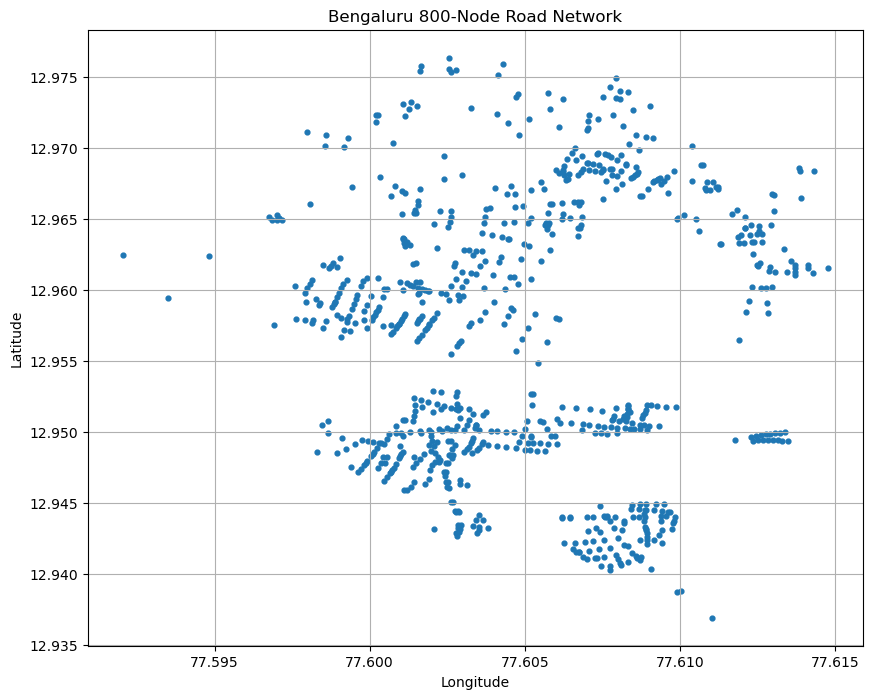

In [8]:
# ============================================================
# STEP 5: Visualize the 800 Bengaluru nodes
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# node_coords_800.npy:
# column 0 = latitude
# column 1 = longitude

latitudes = node_coords[:, 0]
longitudes = node_coords[:, 1]

plt.figure(figsize=(10, 8))

plt.scatter(
    longitudes,
    latitudes,
    s=12
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bengaluru 800-Node Road Network")
plt.grid(True)

plt.show()

Depot index: 161
Customer indices: [613 684 519 348 557  68 344  70]


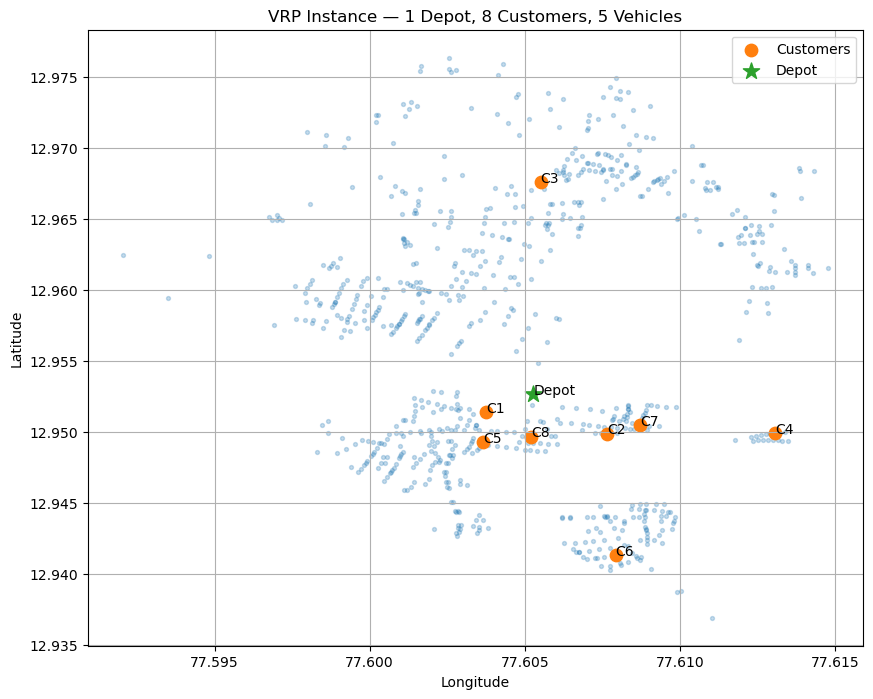

In [9]:
# STEP 6: Create a reproducible VRP instance
import numpy as np
import matplotlib.pyplot as plt

# Fixed seed so we always get the same VRP instance
rng = np.random.default_rng(42)

num_vehicles = 5
num_customers = 8

# Randomly choose 9 distinct nodes
selected_indices = rng.choice(len(node_coords), size=num_customers + 1, replace=False)

depot_idx = selected_indices[0]
customer_indices = selected_indices[1:]

print("Depot index:", depot_idx)
print("Customer indices:", customer_indices)

# Visualize the selected VRP nodes
plt.figure(figsize=(10, 8))

# All network nodes
plt.scatter(
    node_coords[:, 1],
    node_coords[:, 0],
    s=8,
    alpha=0.25
)

# Customers
plt.scatter(
    node_coords[customer_indices, 1],
    node_coords[customer_indices, 0],
    s=80,
    marker='o',
    label='Customers'
)

# Depot
plt.scatter(
    node_coords[depot_idx, 1],
    node_coords[depot_idx, 0],
    s=150,
    marker='*',
    label='Depot'
)

# Label customers
for i, idx in enumerate(customer_indices, start=1):
    lon = node_coords[idx, 1]
    lat = node_coords[idx, 0]
    plt.text(lon, lat, f"C{i}", fontsize=10)

# Label depot
plt.text(
    node_coords[depot_idx, 1],
    node_coords[depot_idx, 0],
    "Depot",
    fontsize=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("VRP Instance — 1 Depot, 8 Customers, 5 Vehicles")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# STEP 7: Correctly verify index -> Graph node mapping

import json
import networkx as nx

# Load graph
G = nx.read_graphml("bengaluru_800.graphml")

# Load mapping
with open("node_index_map.json", "r") as f:
    node_index_map = json.load(f)

index_to_node = node_index_map["index_to_node"]

selected = [int(depot_idx)] + [int(x) for x in customer_indices]

print("Selected indices:")
print(selected)

print("\nIndex -> Graph node ID:")

all_valid = True

for idx in selected:
    graph_node = index_to_node[str(idx)]

    exists = str(graph_node) in G.nodes

    print(f"Index {idx} -> Node {graph_node} | Exists: {exists}")

    if not exists:
        all_valid = False

print("\nAll selected nodes valid:", all_valid)

Selected indices:
[161, 613, 684, 519, 348, 557, 68, 344, 70]

Index -> Graph node ID:
Index 161 -> Node 4294224252 | Exists: True
Index 613 -> Node 2473502259 | Exists: True
Index 684 -> Node 9189234362 | Exists: True
Index 519 -> Node 1274615185 | Exists: True
Index 348 -> Node 2228165651 | Exists: True
Index 557 -> Node 2227895766 | Exists: True
Index 68 -> Node 443252894 | Exists: True
Index 344 -> Node 10053692415 | Exists: True
Index 70 -> Node 12183357600 | Exists: True

All selected nodes valid: True


In [12]:
import numpy as np

# Fixed problem setup
depot = 161
destinations = [613, 684, 519, 348, 557, 68, 344, 70]
n_destinations = len(destinations)
n_vehicles = 5

# One QPSO particle = 12 continuous values
# 8 values -> destination ordering
# 4 values -> route split positions
particle = np.random.uniform(0, 1, 12)

print("Particle:")
print(particle)

Particle:
[0.97537378 0.45886616 0.27879831 0.70360965 0.76483204 0.70355469
 0.71488149 0.7223394  0.56296626 0.84674483 0.61047882 0.37376715]


In [72]:
def decode_particle(particle, destinations, n_vehicles):
    n = len(destinations)

    # First n dimensions determine destination ordering
    order_keys = particle[:n]

    sorted_indices = np.argsort(order_keys)

    ordered_destinations = [
        destinations[i]
        for i in sorted_indices
    ]

    # Remaining dimensions determine route separators
    split_keys = particle[n:]

    sorted_split_keys = np.sort(split_keys)

    n_splits = n_vehicles - 1

    span = n - n_vehicles + 1

    base_positions = np.arange(1, n_splits + 1)

    split_positions = (
        np.floor(sorted_split_keys * span).astype(int)
        + base_positions
    )

    routes = []

    start = 0

    for split in split_positions:
        routes.append(
            ordered_destinations[start:split]
        )
        start = split

    routes.append(
        ordered_destinations[start:]
    )

    return routes

In [20]:
def evaluate_route(route, G, depot):
    """
    Evaluate one vehicle route.

    Vehicle travels:
    depot -> destination 1 -> destination 2 -> ... -> depot

    Returns:
        distance
        travel_time
        congestion
        emissions
    """

    if len(route) == 0:
        return {
            "distance": 0.0,
            "travel_time": 0.0,
            "congestion": 0.0,
            "emissions": 0.0
        }

    full_route = [depot] + route + [depot]

    total_distance = 0.0
    total_time = 0.0
    total_congestion = 0.0
    total_emissions = 0.0

    for i in range(len(full_route) - 1):

        source = full_route[i]
        target = full_route[i + 1]

        # Shortest road path between two consecutive destinations
        path = nx.shortest_path(
            G,
            source=source,
            target=target,
            weight="effective_weight"
        )

        # Evaluate every edge in that road path
        for u, v in zip(path[:-1], path[1:]):

            edge_data = G.get_edge_data(u, v)

            # MultiGraph can have multiple edges between u and v.
            # Select the edge with minimum effective weight.
            best_edge = min(
                edge_data.values(),
                key=lambda x: x["effective_weight"]
            )

            distance = best_edge["length"]
            travel_time = best_edge["travel_time"]
            traffic_factor = best_edge["traffic_factor"]

            total_distance += distance
            total_time += travel_time

            # Congestion contribution
            total_congestion += traffic_factor

            # PRD emission proxy:
            # edge_distance × vehicle_weight_factor
            #
            # The current dataset does not provide
            # vehicle_weight_factor, so for this test
            # we use 1.0 as an implementation placeholder.
            vehicle_weight_factor = 1.0

            total_emissions += (
                distance * vehicle_weight_factor
            )

    return {
        "distance": total_distance,
        "travel_time": total_time,
        "congestion": total_congestion,
        "emissions": total_emissions
    }

    # Test Vehicle 1 from our decoded solution
    test_route = routes[0]
    
    result = evaluate_route(
        test_route,
        G,
        depot
    )
    
    print("Route:", test_route)
    print("Evaluation:")
    print(result)

In [22]:
import numpy as np

# Reproducible traffic scenario
np.random.seed(42)

# Keep original graph unchanged
G_traffic = G.copy()

# Synthetic traffic levels
traffic_levels = [1.0, 1.2, 1.5, 1.8, 2.0]

# Assign traffic to every edge
for u, v, key, data in G_traffic.edges(keys=True, data=True):

    traffic_factor = np.random.choice(traffic_levels)

    # Store traffic factor
    data["traffic_factor"] = float(traffic_factor)

    # Convert travel_time to numeric
    base_travel_time = float(data["travel_time"])

    # Traffic-adjusted travel time
    data["traffic_travel_time"] = (
        base_travel_time * traffic_factor
    )

print("Synthetic traffic scenario created.")

traffic_values = [
    data["traffic_factor"]
    for _, _, _, data in G_traffic.edges(
        keys=True, data=True
    )
]

print("Traffic factor statistics:")
print("Minimum:", min(traffic_values))
print("Maximum:", max(traffic_values))
print("Mean:", np.mean(traffic_values))

Synthetic traffic scenario created.
Traffic factor statistics:
Minimum: 1.0
Maximum: 2.0
Mean: 1.499621212121212


In [27]:
# Convert dataset indices to actual NetworkX node IDs

depot_node = int(index_to_node[str(depot)])

destination_nodes = [
    int(index_to_node[str(node)])
    for node in destinations
]

print("Depot:")
print(depot, "->", depot_node)

print("\nDestinations:")
for old, new in zip(destinations, destination_nodes):
    print(old, "->", new)

Depot:
161 -> 4294224252

Destinations:
613 -> 2473502259
684 -> 9189234362
519 -> 1274615185
348 -> 2228165651
557 -> 2227895766
68 -> 443252894
344 -> 10053692415
70 -> 12183357600


In [28]:
# Convert decoded routes from dataset indices to actual graph node IDs

routes_graph = [
    [int(index_to_node[str(node)]) for node in route]
    for route in routes
]

print("Decoded routes with actual graph node IDs:")

for i, route in enumerate(routes_graph, start=1):
    print(f"Vehicle {i}: {route}")

Decoded routes with actual graph node IDs:
Vehicle 1: [1274615185]
Vehicle 2: [9189234362, 443252894]
Vehicle 3: [2228165651, 10053692415]
Vehicle 4: [12183357600, 2227895766]
Vehicle 5: [2473502259]


In [41]:
def evaluate_route(route, G, depot):
    """
    Evaluate one vehicle route.

    Route:
        depot -> destination(s) -> depot

    Uses traffic-aware shortest paths.

    Returns:
        distance
        traffic-adjusted travel time
        congestion
        emissions
    """

    if len(route) == 0:
        return {
            "distance": 0.0,
            "travel_time": 0.0,
            "congestion": 0.0,
            "emissions": 0.0
        }

    full_route = [depot] + route + [depot]

    total_distance = 0.0
    total_time = 0.0
    total_congestion = 0.0
    total_emissions = 0.0

    # Temporary implementation value for testing.
    # PRD does not specify actual vehicle weight factors.
    vehicle_weight_factor = 1.0

    for i in range(len(full_route) - 1):

        source = full_route[i]
        target = full_route[i + 1]

        # Traffic-aware shortest path
        path = nx.shortest_path(
            G,
            source=source,
            target=target,
            weight="traffic_weight"
        )

        for u, v in zip(path[:-1], path[1:]):

            edge_data = G.get_edge_data(u, v)

            best_edge = min(
                edge_data.values(),
                key=lambda x: float(x["traffic_weight"])
            )

            distance = float(best_edge["length"])
            traffic_factor = float(best_edge["traffic_factor"])
            traffic_time = float(best_edge["traffic_weight"])

            total_distance += distance
            total_time += traffic_time
            total_congestion += traffic_factor

            total_emissions += (
                distance * vehicle_weight_factor
            )

    return {
        "distance": total_distance,
        "travel_time": total_time,
        "congestion": total_congestion,
        "emissions": total_emissions
    }

In [33]:
print("Number of nodes:", len(G_traffic.nodes))

print("\nFirst 10 graph node IDs:")
print(list(G_traffic.nodes)[:10])

print("\nDepot node:", depot_node)
print("Depot exists in G_traffic:", depot_node in G_traffic)

print("\nType of depot_node:", type(depot_node))
print("Type of first graph node:", type(list(G_traffic.nodes)[0]))

Number of nodes: 800

First 10 graph node IDs:
['11387494406', '1833752585', '1833752587', '12864985109', '11919132703', '443252777', '443252782', '11356383282', '11356383283', '6458368052']

Depot node: 4294224252
Depot exists in G_traffic: False

Type of depot_node: <class 'int'>
Type of first graph node: <class 'str'>


In [34]:
# Convert depot and destination node IDs to the same type
# used by G_traffic: strings.

depot_node = str(depot_node)

routes_graph = [
    [str(node) for node in route]
    for route in routes_graph
]

print("Depot:", depot_node)
print("Depot exists:", depot_node in G_traffic)

print("\nRoutes:")
for i, route in enumerate(routes_graph, start=1):
    print(f"Vehicle {i}: {route}")

Depot: 4294224252
Depot exists: True

Routes:
Vehicle 1: ['1274615185']
Vehicle 2: ['9189234362', '443252894']
Vehicle 3: ['2228165651', '10053692415']
Vehicle 4: ['12183357600', '2227895766']
Vehicle 5: ['2473502259']


In [37]:
# Inspect the types of the edge attributes used by the evaluator

u, v, key, data = next(iter(G_traffic.edges(keys=True, data=True)))

print("Sample edge:")
print(u, "->", v)

print("\nAttribute values and types:")

for attr in ["length", "speed_kph", "travel_time",
             "traffic_factor", "effective_weight"]:
    print(
        attr,
        "=",
        data[attr],
        "| type =",
        type(data[attr])
    )

Sample edge:
11387494406 -> 248455238

Attribute values and types:
length = 38.41449566495511 | type = <class 'str'>
speed_kph = 28.295270690728064 | type = <class 'str'>
travel_time = 4.887466386358151 | type = <class 'str'>
traffic_factor = 1.8 | type = <class 'float'>
effective_weight = 4.887466386358151 | type = <class 'str'>


In [38]:
# Convert numeric edge attributes from strings to floats

for u, v, key, data in G_traffic.edges(keys=True, data=True):

    data["length"] = float(data["length"])
    data["speed_kph"] = float(data["speed_kph"])
    data["travel_time"] = float(data["travel_time"])
    data["effective_weight"] = float(data["effective_weight"])
    data["traffic_factor"] = float(data["traffic_factor"])

print("Graph edge attributes converted to numeric types.")

# Verify
u, v, key, data = next(iter(G_traffic.edges(keys=True, data=True)))

for attr in ["length", "speed_kph", "travel_time",
             "traffic_factor", "effective_weight"]:
    print(attr, "->", type(data[attr]))

Graph edge attributes converted to numeric types.
length -> <class 'float'>
speed_kph -> <class 'float'>
travel_time -> <class 'float'>
traffic_factor -> <class 'float'>
effective_weight -> <class 'float'>


In [39]:
test_result = evaluate_route(
    routes_graph[0],
    G_traffic,
    depot_node
)

print("Route:", routes_graph[0])
print("\nRoute evaluation:")

for key, value in test_result.items():
    print(f"{key}: {value:.3f}")

Route: ['1274615185']

Route evaluation:
distance: 3595.070
travel_time: 666.901
congestion: 22.600
emissions: 3595.070


In [40]:
# Create a traffic-aware edge weight.
# Implementation choice:
# traffic_weight = base travel_time × traffic_factor

for u, v, key, data in G_traffic.edges(keys=True, data=True):
    data["traffic_weight"] = (
        float(data["travel_time"])
        * float(data["traffic_factor"])
    )

# Verify
u, v, key, data = next(iter(G_traffic.edges(keys=True, data=True)))

print("Base travel time:", data["travel_time"])
print("Traffic factor:", data["traffic_factor"])
print("Traffic-aware weight:", data["traffic_weight"])

Base travel time: 4.887466386358151
Traffic factor: 1.8
Traffic-aware weight: 8.79743949544467


In [42]:
test_result = evaluate_route(
    routes_graph[0],
    G_traffic,
    depot_node
)

print("Route:", routes_graph[0])
print("\nTraffic-aware route evaluation:")

for key, value in test_result.items():
    print(f"{key}: {value:.3f}")

Route: ['1274615185']

Traffic-aware route evaluation:
distance: 3592.860
travel_time: 596.220
congestion: 18.000
emissions: 3592.860


In [43]:
def evaluate_solution(routes, G, depot):
    """
    Evaluate a complete multi-vehicle solution.

    routes:
        List of routes, one route per vehicle.

    Returns:
        Total distance
        Total travel time
        Total congestion
        Total emissions
    """

    total_distance = 0.0
    total_travel_time = 0.0
    total_congestion = 0.0
    total_emissions = 0.0

    vehicle_results = []

    for vehicle_id, route in enumerate(routes, start=1):

        result = evaluate_route(
            route,
            G,
            depot
        )

        vehicle_results.append({
            "vehicle": vehicle_id,
            "distance": result["distance"],
            "travel_time": result["travel_time"],
            "congestion": result["congestion"],
            "emissions": result["emissions"]
        })

        total_distance += result["distance"]
        total_travel_time += result["travel_time"]
        total_congestion += result["congestion"]
        total_emissions += result["emissions"]

    return {
        "distance": total_distance,
        "travel_time": total_travel_time,
        "congestion": total_congestion,
        "emissions": total_emissions,
        "vehicle_results": vehicle_results
    }

In [44]:
solution_result = evaluate_solution(
    routes_graph,
    G_traffic,
    depot_node
)

print("Complete 5-vehicle solution:")
print()

for key in ["distance", "travel_time", "congestion", "emissions"]:
    print(f"{key}: {solution_result[key]:.3f}")

print("\nPer-vehicle results:")

for result in solution_result["vehicle_results"]:
    print(
        f"Vehicle {result['vehicle']}: "
        f"distance={result['distance']:.3f}, "
        f"time={result['travel_time']:.3f}, "
        f"congestion={result['congestion']:.3f}, "
        f"emissions={result['emissions']:.3f}"
    )

Complete 5-vehicle solution:

distance: 12549.323
travel_time: 1832.963
congestion: 176.500
emissions: 12549.323

Per-vehicle results:
Vehicle 1: distance=3592.860, time=596.220, congestion=18.000, emissions=3592.860
Vehicle 2: distance=3692.215, time=427.354, congestion=52.600, emissions=3692.215
Vehicle 3: distance=3524.832, time=530.709, congestion=64.800, emissions=3524.832
Vehicle 4: distance=1274.520, time=216.878, congestion=35.700, emissions=1274.520
Vehicle 5: distance=464.896, time=61.803, congestion=5.400, emissions=464.896


In [45]:
def normalize_objectives(results):
    """
    Normalize the four objective values to [0, 1]
    using min-max normalization.

    Lower value = better.

    results:
        List of solution evaluation dictionaries.
    """

    objectives = [
        "travel_time",
        "distance",
        "congestion",
        "emissions"
    ]

    normalized = []

    for result in results:
        normalized_result = {}

        for objective in objectives:

            values = [
                r[objective]
                for r in results
            ]

            min_value = min(values)
            max_value = max(values)

            # Avoid division by zero when all solutions
            # have the same objective value.
            if max_value == min_value:
                normalized_value = 0.0
            else:
                normalized_value = (
                    (result[objective] - min_value)
                    / (max_value - min_value)
                )

            normalized_result[objective] = normalized_value

        normalized.append(normalized_result)

    return normalized

In [46]:
def calculate_fitness(normalized_result):
    """
    Calculate the weighted multi-objective fitness.

    Lower fitness = better solution.

    PRD objective weights:
        Travel time  = 0.40
        Distance     = 0.30
        Congestion   = 0.20
        Environmental= 0.10
    """

    fitness = (
        0.40 * normalized_result["travel_time"]
        + 0.30 * normalized_result["distance"]
        + 0.20 * normalized_result["congestion"]
        + 0.10 * normalized_result["emissions"]
    )

    return fitness

In [47]:
test_normalized = {
    "travel_time": 0.2,
    "distance": 0.4,
    "congestion": 0.6,
    "emissions": 0.3
}

test_fitness = calculate_fitness(test_normalized)

print("Test fitness:", test_fitness)

Test fitness: 0.35


In [48]:
def evaluate_particle(
    particle,
    destinations,
    n_vehicles,
    G,
    depot,
    all_results
):
    """
    Evaluate one particle.

    Steps:
        1. Decode particle into vehicle routes
        2. Evaluate the complete multi-vehicle solution
        3. Normalize objectives
        4. Calculate weighted fitness
    """

    # Step 1: Decode particle
    routes = decode_particle(
        particle,
        destinations,
        n_vehicles
    )

    # Step 2: Convert route indices to graph node IDs
    routes_graph = [
        [str(index_to_node[str(node)]) for node in route]
        for route in routes
    ]

    # Step 3: Evaluate complete solution
    solution = evaluate_solution(
        routes_graph,
        G,
        depot
    )

    # Add this solution to the candidate set
    candidate_results = all_results + [solution]

    # Step 4: Normalize objectives
    normalized_results = normalize_objectives(
        candidate_results
    )

    # Step 5: Fitness
    fitness = calculate_fitness(
        normalized_results[-1]
    )

    return {
        "particle": particle,
        "routes": routes_graph,
        "solution": solution,
        "normalized": normalized_results[-1],
        "fitness": fitness
    }

In [49]:
def evaluate_particles(
    particles,
    destinations,
    n_vehicles,
    G,
    depot
):
    """
    Evaluate a batch of particles.

    Each particle is:
        [8 destination-order keys + 4 split keys]

    Returns:
        evaluated_particles
        normalized_results
        fitness_values
    """

    solutions = []
    decoded_routes = []

    # Evaluate every particle first
    for particle in particles:

        routes = decode_particle(
            particle,
            destinations,
            n_vehicles
        )

        routes_graph = [
            [str(index_to_node[str(node)]) for node in route]
            for route in routes
        ]

        solution = evaluate_solution(
            routes_graph,
            G,
            depot
        )

        decoded_routes.append(routes_graph)
        solutions.append(solution)

    # Normalize all solutions together
    normalized_results = normalize_objectives(
        solutions
    )

    # Calculate fitness for every particle
    fitness_values = []

    for normalized in normalized_results:

        fitness = calculate_fitness(
            normalized
        )

        fitness_values.append(fitness)

    # Store everything together
    evaluated_particles = []

    for i in range(len(particles)):

        evaluated_particles.append({
            "particle": particles[i],
            "routes": decoded_routes[i],
            "solution": solutions[i],
            "normalized": normalized_results[i],
            "fitness": fitness_values[i]
        })

    return evaluated_particles

In [50]:
np.random.seed(42)

test_particles = np.random.rand(5, 12)

evaluated = evaluate_particles(
    test_particles,
    destinations,
    5,
    G_traffic,
    depot_node
)

for i, result in enumerate(evaluated, start=1):

    print(
        f"Particle {i}: "
        f"fitness={result['fitness']:.4f}"
    )

Particle 1: fitness=0.7279
Particle 2: fitness=0.2961
Particle 3: fitness=1.0000
Particle 4: fitness=1.0000
Particle 5: fitness=0.0000


In [51]:
best_result = min(
    evaluated,
    key=lambda x: x["fitness"]
)

print("Best fitness:", best_result["fitness"])

print("\nBest routes:")

for i, route in enumerate(best_result["routes"], start=1):
    print(f"Vehicle {i}: {route}")

Best fitness: 0.0

Best routes:
Vehicle 1: ['9189234362']
Vehicle 2: ['2473502259', '10053692415']
Vehicle 3: ['2228165651', '443252894']
Vehicle 4: ['12183357600', '2227895766']
Vehicle 5: ['1274615185']


In [52]:
# QPSO swarm configuration

n_particles = 25
n_dimensions = 12

np.random.seed(42)

swarm = np.random.rand(
    n_particles,
    n_dimensions
)

print("Swarm shape:", swarm.shape)
print("First particle:", swarm[0])

Swarm shape: (25, 12)
First particle: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]


In [53]:
# Evaluate the initial QPSO swarm

evaluated_swarm = evaluate_particles(
    swarm,
    destinations,
    5,
    G_traffic,
    depot_node
)

# Current positions
positions = swarm.copy()

# Personal best positions initially equal current positions
pbest_positions = positions.copy()

# Personal best fitness values
pbest_fitness = np.array([
    result["fitness"]
    for result in evaluated_swarm
])

# Global best particle
best_index = np.argmin(pbest_fitness)

gbest_position = pbest_positions[best_index].copy()
gbest_fitness = pbest_fitness[best_index]

print("Number of particles:", len(positions))
print("Particle dimensions:", positions.shape[1])
print("Initial global best fitness:", gbest_fitness)
print("Global best particle index:", best_index)

Number of particles: 25
Particle dimensions: 12
Initial global best fitness: 0.0
Global best particle index: 14


In [54]:
beta_max = 1.0
beta_min = 0.5

T_max = 200

iteration = 0

beta = beta_max

print("Iteration:", iteration)
print("Beta:", beta)
print("Maximum iterations:", T_max)

Iteration: 0
Beta: 1.0
Maximum iterations: 200


In [55]:
# Calculate mbest for QPSO

mbest = np.mean(
    pbest_positions,
    axis=0
)

print("MBEST shape:", mbest.shape)
print("MBEST:")
print(mbest)

MBEST shape: (12,)
MBEST:
[0.50861243 0.4862478  0.53827362 0.4755699  0.47760088 0.49252486
 0.46069715 0.58239965 0.52376332 0.46251745 0.50359715 0.43065098]


In [56]:
def qpso_position_update(
    positions,
    pbest_positions,
    gbest_position,
    mbest,
    beta
):
    """
    Standard QPSO position update.

    Returns:
        new_positions
    """

    n_particles, n_dimensions = positions.shape

    # Random numbers for the local attractor
    phi = np.random.rand(
        n_particles,
        n_dimensions
    )

    # Local attractor:
    # p = phi * pbest + (1 - phi) * gbest
    local_attractor = (
        phi * pbest_positions
        + (1 - phi) * gbest_position
    )

    # Random number for logarithmic term
    u = np.random.rand(
        n_particles,
        n_dimensions
    )

    # Prevent log(0)
    u = np.clip(u, 1e-12, 1.0)

    # Random direction: +1 or -1
    direction = np.where(
        np.random.rand(
            n_particles,
            n_dimensions
        ) < 0.5,
        -1.0,
        1.0
    )

    # QPSO position update
    new_positions = (
        local_attractor
        + direction
        * beta
        * np.abs(mbest - positions)
        * np.log(1.0 / u)
    )

    return new_positions

In [57]:
new_positions = qpso_position_update(
    positions,
    pbest_positions,
    gbest_position,
    mbest,
    beta
)

print("Old position shape:", positions.shape)
print("New position shape:", new_positions.shape)
print("\nFirst old particle:")
print(positions[0])

print("\nFirst new particle:")
print(new_positions[0])

Old position shape: (25, 12)
New position shape: (25, 12)

First old particle:
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]

First new particle:
[-0.18038817  0.18849151  0.3715552   0.68579507 -0.42658904  0.41845322
  0.97748746  0.11121623  0.5664227   0.38278771  2.09770444  0.08209744]


In [58]:
new_evaluated_swarm = evaluate_particles(
    new_positions,
    destinations,
    5,
    G_traffic,
    depot_node
)

print("Number of evaluated particles:", len(new_evaluated_swarm))

for i, result in enumerate(new_evaluated_swarm[:5], start=1):
    print(
        f"Particle {i}: "
        f"fitness={result['fitness']:.4f}"
    )

Number of evaluated particles: 25
Particle 1: fitness=0.2156
Particle 2: fitness=0.7833
Particle 3: fitness=0.2214
Particle 4: fitness=1.0000
Particle 5: fitness=0.0866


In [59]:
best_new_result = min(
    new_evaluated_swarm,
    key=lambda x: x["fitness"]
)

print("Best new fitness:", best_new_result["fitness"])

print("\nBest new routes:")

for i, route in enumerate(
    best_new_result["routes"],
    start=1
):
    print(f"Vehicle {i}: {route}")

Best new fitness: 0.08663633410813787

Best new routes:
Vehicle 1: ['12183357600']
Vehicle 2: ['2473502259', '443252894']
Vehicle 3: ['10053692415', '9189234362']
Vehicle 4: ['2227895766', '2228165651']
Vehicle 5: ['1274615185']


In [60]:
# Fitness values of the newly evaluated particles

new_fitness = np.array([
    result["fitness"]
    for result in new_evaluated_swarm
])

# Check which particles improved
improved = new_fitness < pbest_fitness

# Update personal-best positions
pbest_positions[improved] = new_positions[improved]

# Update personal-best fitness values
pbest_fitness[improved] = new_fitness[improved]

print("Particles that improved:", np.sum(improved))
print("Best personal-best fitness:", np.min(pbest_fitness))

Particles that improved: 16
Best personal-best fitness: 0.0


In [61]:
best_index = np.argmin(pbest_fitness)

gbest_position = pbest_positions[best_index].copy()
gbest_fitness = pbest_fitness[best_index]

print("Global best fitness:", gbest_fitness)
print("Global best particle index:", best_index)

Global best fitness: 0.0
Global best particle index: 14


In [62]:
# Move to the next iteration

iteration += 1

beta = (
    beta_max
    - (iteration / (T_max - 1))
    * (beta_max - beta_min)
)

# Recalculate MBEST from updated personal best positions

mbest = np.mean(
    pbest_positions,
    axis=0
)

print("Iteration:", iteration)
print("Beta:", beta)
print("MBEST shape:", mbest.shape)

Iteration: 1
Beta: 0.9974874371859297
MBEST shape: (12,)


In [63]:
# Run one complete QPSO iteration

# 1. Generate new particle positions
new_positions = qpso_position_update(
    positions,
    pbest_positions,
    gbest_position,
    mbest,
    beta
)

# 2. Evaluate the new positions
new_evaluated_swarm = evaluate_particles(
    new_positions,
    destinations,
    5,
    G_traffic,
    depot_node
)

# 3. Get new fitness values
new_fitness = np.array([
    result["fitness"]
    for result in new_evaluated_swarm
])

# 4. Update personal bests
improved = new_fitness < pbest_fitness

pbest_positions[improved] = new_positions[improved]
pbest_fitness[improved] = new_fitness[improved]

# 5. Update global best
best_index = np.argmin(pbest_fitness)

gbest_position = pbest_positions[best_index].copy()
gbest_fitness = pbest_fitness[best_index]

# 6. Update current positions
positions = new_positions.copy()

# 7. Update MBEST
mbest = np.mean(
    pbest_positions,
    axis=0
)

# 8. Move to next iteration
iteration += 1

beta = (
    beta_max
    - (iteration / (T_max - 1))
    * (beta_max - beta_min)
)

print("Iteration:", iteration)
print("Beta:", beta)
print("Improved particles:", np.sum(improved))
print("Global best fitness:", gbest_fitness)

Iteration: 2
Beta: 0.9949748743718593
Improved particles: 5
Global best fitness: 0.0


In [64]:
# Reset QPSO state for a clean optimization run

np.random.seed(42)

iteration = 0

beta_max = 1.0
beta_min = 0.5
T_max = 200

# Initial swarm
positions = np.random.rand(
    n_particles,
    n_dimensions
)

# Evaluate initial swarm
evaluated_swarm = evaluate_particles(
    positions,
    destinations,
    5,
    G_traffic,
    depot_node
)

# Initialize personal bests
pbest_positions = positions.copy()

pbest_fitness = np.array([
    result["fitness"]
    for result in evaluated_swarm
])

# Initialize global best
best_index = np.argmin(pbest_fitness)

gbest_position = pbest_positions[best_index].copy()
gbest_fitness = pbest_fitness[best_index]

# Initialize MBEST
mbest = np.mean(
    pbest_positions,
    axis=0
)

# Store convergence
convergence = [gbest_fitness]

print("Initial fitness:", gbest_fitness)
print("Initial beta:", beta_max)

Initial fitness: 0.0
Initial beta: 1.0


In [65]:
for iteration in range(T_max):

    # Calculate beta for this iteration
    beta = (
        beta_max
        - (iteration / (T_max - 1))
        * (beta_max - beta_min)
    )

    # Calculate MBEST from current personal bests
    mbest = np.mean(
        pbest_positions,
        axis=0
    )

    # QPSO position update
    new_positions = qpso_position_update(
        positions,
        pbest_positions,
        gbest_position,
        mbest,
        beta
    )

    # Evaluate new particles
    evaluated_swarm = evaluate_particles(
        new_positions,
        destinations,
        5,
        G_traffic,
        depot_node
    )

    # Extract fitness
    new_fitness = np.array([
        result["fitness"]
        for result in evaluated_swarm
    ])

    # Update personal bests
    improved = new_fitness < pbest_fitness

    pbest_positions[improved] = (
        new_positions[improved]
    )

    pbest_fitness[improved] = (
        new_fitness[improved]
    )

    # Update global best
    best_index = np.argmin(
        pbest_fitness
    )

    if pbest_fitness[best_index] < gbest_fitness:

        gbest_fitness = (
            pbest_fitness[best_index]
        )

        gbest_position = (
            pbest_positions[best_index].copy()
        )

    # Update current positions
    positions = new_positions.copy()

    # Store convergence
    convergence.append(gbest_fitness)

    # Progress
    if (iteration + 1) % 10 == 0:
        print(
            f"Iteration {iteration + 1:3d} | "
            f"Beta = {beta:.4f} | "
            f"Best fitness = {gbest_fitness:.6f}"
        )

Iteration  10 | Beta = 0.9774 | Best fitness = 0.000000
Iteration  20 | Beta = 0.9523 | Best fitness = 0.000000
Iteration  30 | Beta = 0.9271 | Best fitness = 0.000000
Iteration  40 | Beta = 0.9020 | Best fitness = 0.000000
Iteration  50 | Beta = 0.8769 | Best fitness = 0.000000
Iteration  60 | Beta = 0.8518 | Best fitness = 0.000000
Iteration  70 | Beta = 0.8266 | Best fitness = 0.000000
Iteration  80 | Beta = 0.8015 | Best fitness = 0.000000
Iteration  90 | Beta = 0.7764 | Best fitness = 0.000000
Iteration 100 | Beta = 0.7513 | Best fitness = 0.000000
Iteration 110 | Beta = 0.7261 | Best fitness = 0.000000
Iteration 120 | Beta = 0.7010 | Best fitness = 0.000000
Iteration 130 | Beta = 0.6759 | Best fitness = 0.000000
Iteration 140 | Beta = 0.6508 | Best fitness = 0.000000
Iteration 150 | Beta = 0.6256 | Best fitness = 0.000000
Iteration 160 | Beta = 0.6005 | Best fitness = 0.000000
Iteration 170 | Beta = 0.5754 | Best fitness = 0.000000
Iteration 180 | Beta = 0.5503 | Best fitness = 0

In [66]:
# Decode the final global-best particle

final_routes = decode_particle(
    gbest_position,
    destinations,
    5
)

final_routes_graph = [
    [str(index_to_node[str(node)]) for node in route]
    for route in final_routes
]

final_solution = evaluate_solution(
    final_routes_graph,
    G_traffic,
    depot_node
)

print("Final QPSO solution")
print("===================")

print(f"Distance:    {final_solution['distance']:.3f}")
print(f"Travel time: {final_solution['travel_time']:.3f}")
print(f"Congestion:  {final_solution['congestion']:.3f}")
print(f"Emissions:   {final_solution['emissions']:.3f}")

print("\nRoutes:")

for i, route in enumerate(final_routes_graph, start=1):
    print(f"Vehicle {i}: {route}")

Final QPSO solution
Distance:    11906.017
Travel time: 1758.724
Congestion:  158.500
Emissions:   11906.017

Routes:
Vehicle 1: ['2228165651']
Vehicle 2: ['2473502259', '12183357600']
Vehicle 3: ['443252894', '2227895766']
Vehicle 4: ['9189234362', '10053692415']
Vehicle 5: ['1274615185']


In [67]:
print("Final QPSO solution:")
print(f"Distance:    {final_solution['distance']:.3f}")
print(f"Travel time: {final_solution['travel_time']:.3f}")
print(f"Congestion:  {final_solution['congestion']:.3f}")
print(f"Emissions:   {final_solution['emissions']:.3f}")

print("\nInitial test solution:")
print(f"Distance:    {solution_result['distance']:.3f}")
print(f"Travel time: {solution_result['travel_time']:.3f}")
print(f"Congestion:  {solution_result['congestion']:.3f}")
print(f"Emissions:   {solution_result['emissions']:.3f}")

Final QPSO solution:
Distance:    11906.017
Travel time: 1758.724
Congestion:  158.500
Emissions:   11906.017

Initial test solution:
Distance:    12549.323
Travel time: 1832.963
Congestion:  176.500
Emissions:   12549.323


In [68]:
# Build a fixed reference set from the initial swarm

reference_solutions = []

for result in evaluated_swarm:
    reference_solutions.append(
        result["solution"]
    )

objectives = [
    "travel_time",
    "distance",
    "congestion",
    "emissions"
]

reference_bounds = {}

for objective in objectives:

    values = np.array([
        solution[objective]
        for solution in reference_solutions
    ])

    reference_bounds[objective] = {
        "min": np.min(values),
        "max": np.max(values)
    }

print("Fixed reference bounds:")
print()

for objective in objectives:
    print(
        f"{objective}: "
        f"min={reference_bounds[objective]['min']:.3f}, "
        f"max={reference_bounds[objective]['max']:.3f}"
    )

Fixed reference bounds:

travel_time: min=1725.861, max=1963.937
distance: min=11836.368, max=13465.127
congestion: min=158.100, max=188.600
emissions: min=11836.368, max=13465.127


In [69]:
def normalize_with_fixed_bounds(solution, reference_bounds):
    """
    Normalize objectives using fixed reference bounds.

    Lower objective value = better.

    Values are clipped to [0, 1].
    """

    normalized = {}

    for objective in [
        "travel_time",
        "distance",
        "congestion",
        "emissions"
    ]:

        min_value = reference_bounds[objective]["min"]
        max_value = reference_bounds[objective]["max"]

        if max_value == min_value:
            value = 0.0

        else:
            value = (
                (solution[objective] - min_value)
                / (max_value - min_value)
            )

        normalized[objective] = np.clip(
            value,
            0.0,
            1.0
        )

    return normalized

In [70]:
final_normalized = normalize_with_fixed_bounds(
    final_solution,
    reference_bounds
)

final_fixed_fitness = calculate_fitness(
    final_normalized
)

print("Final normalized objectives:")

for objective, value in final_normalized.items():
    print(f"{objective}: {value:.4f}")

print(
    f"\nFinal fixed-reference fitness: "
    f"{final_fixed_fitness:.4f}"
)

Final normalized objectives:
travel_time: 0.1380
distance: 0.0428
congestion: 0.0131
emissions: 0.0428

Final fixed-reference fitness: 0.0749


In [71]:
split_positions = np.argsort(split_keys)
gaps = np.linspace(1, n - 1, n_vehicles - 1, dtype=int)
split_positions = gaps[split_positions]
split_positions = sorted(split_positions)

NameError: name 'split_keys' is not defined

In [73]:
test_particle = np.random.rand(12)

test_routes = decode_particle(
    test_particle,
    destinations,
    n_vehicles=5
)

print("Decoded routes:")

for i, route in enumerate(test_routes, start=1):
    print(f"Vehicle {i}: {route}")

print("\nRoute sizes:")
print([len(route) for route in test_routes])

Decoded routes:
Vehicle 1: [557, 70]
Vehicle 2: [348]
Vehicle 3: [519]
Vehicle 4: [344, 613, 684]
Vehicle 5: [68]

Route sizes:
[2, 1, 1, 3, 1]


In [74]:
print("Total destinations:", sum(len(route) for route in test_routes))
print("Expected destinations:", len(destinations))

print("All destinations:", sorted(
    [node for route in test_routes for node in route]
))

print("Original destinations:", sorted(destinations))

Total destinations: 8
Expected destinations: 8
All destinations: [68, 70, 344, 348, 519, 557, 613, 684]
Original destinations: [68, 70, 344, 348, 519, 557, 613, 684]


In [75]:
# Reinitialize QPSO experiment from scratch

n_particles = 25
n_dimensions = 12
n_vehicles = 5

np.random.seed(42)

positions = np.random.rand(
    n_particles,
    n_dimensions
)

print("Swarm shape:", positions.shape)
print("First particle:")
print(positions[0])

Swarm shape: (25, 12)
First particle:
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]


In [76]:
evaluated_swarm = evaluate_particles(
    positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node
)

initial_fitness = np.array([
    result["fitness"]
    for result in evaluated_swarm
])

print("Initial swarm evaluated:", len(evaluated_swarm))
print("Initial fitness values:")
print(initial_fitness)

print("\nInitial best fitness:", initial_fitness.min())
print("Initial best particle index:", initial_fitness.argmin())

Initial swarm evaluated: 25
Initial fitness values:
[0.51535543 0.79053623 1.         0.38385923 0.18161627 0.89458231
 0.57145902 0.89595392 0.38385923 0.89595392 1.         0.79097362
 0.57145902 0.57145902 0.         0.29258009 0.53339718 0.89595392
 0.82516715 1.         0.89458231 0.79053623 0.17483285 0.62033572
 0.89458231]

Initial best fitness: 0.0
Initial best particle index: 14


In [77]:
pbest_positions = positions.copy()

pbest_fitness = initial_fitness.copy()

best_index = np.argmin(pbest_fitness)

gbest_position = pbest_positions[best_index].copy()

gbest_fitness = pbest_fitness[best_index]

mbest = np.mean(pbest_positions, axis=0)

print("Initial pbest shape:", pbest_positions.shape)
print("Initial gbest fitness:", gbest_fitness)
print("Initial gbest index:", best_index)
print("MBEST shape:", mbest.shape)

Initial pbest shape: (25, 12)
Initial gbest fitness: 0.0
Initial gbest index: 14
MBEST shape: (12,)


In [78]:
beta_max = 1.0
beta_min = 0.5
T_max = 200

iteration = 0

beta = beta_max - (
    iteration / (T_max - 1)
) * (beta_max - beta_min)

print("Iteration:", iteration)
print("Beta:", beta)

Iteration: 0
Beta: 1.0


In [79]:
new_positions = qpso_position_update(
    positions,
    pbest_positions,
    gbest_position,
    mbest,
    beta
)

print("New positions shape:", new_positions.shape)

print("\nFirst particle - old:")
print(positions[0])

print("\nFirst particle - new:")
print(new_positions[0])

print("\nNew position range:")
print("Min:", new_positions.min())
print("Max:", new_positions.max())

New positions shape: (25, 12)

First particle - old:
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]

First particle - new:
[-0.18038817  0.18849151  0.3715552   0.68579507 -0.42658904  0.41845322
  0.97748746  0.11121623  0.5664227   0.38278771  2.09770444  0.08209744]

New position range:
Min: -1.358736882154128
Max: 2.771416696130147


In [80]:
new_evaluated_swarm = evaluate_particles(
    new_positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node
)

new_fitness = np.array([
    result["fitness"]
    for result in new_evaluated_swarm
])

print("New swarm evaluated:", len(new_evaluated_swarm))

print("\nNew fitness values:")
print(new_fitness)

print("\nNew best fitness:", new_fitness.min())
print("New best particle index:", new_fitness.argmin())

New swarm evaluated: 25

New fitness values:
[4.82228116e-02 1.00000000e+00 1.57727321e-01 1.42056526e-01
 1.16288057e-01 7.68087395e-02 9.24795345e-02 9.24795345e-02
 1.16364525e-01 1.42056526e-01 7.07679320e-01 2.13240652e-05
 9.24795345e-02 2.15969040e-01 1.32146384e-01 1.08532021e-01
 4.82992805e-02 1.16364525e-01 1.08532021e-01 9.93146600e-03
 5.89392334e-02 7.38037486e-02 1.42056526e-01 1.26010666e-01
 6.48605756e-01]

New best fitness: 2.1324065160878627e-05
New best particle index: 11


In [81]:
best_new_index = np.argmin(new_fitness)

best_new_result = new_evaluated_swarm[best_new_index]

print("Best new particle:", best_new_index)
print("Fitness:", best_new_result["fitness"])

print("\nRoutes:")
for i, route in enumerate(best_new_result["routes"], start=1):
    print(f"Vehicle {i}: {route}")

print("\nRaw objectives:")
for objective in ["travel_time", "distance", "congestion", "emissions"]:
    print(
        f"{objective}: "
        f"{best_new_result['solution'][objective]:.3f}"
    )

Best new particle: 11
Fitness: 2.1324065160878627e-05

Routes:
Vehicle 1: ['12183357600', '2473502259']
Vehicle 2: ['2228165651', '1274615185']
Vehicle 3: ['10053692415', '9189234362']
Vehicle 4: ['2227895766', '443252894']
Vehicle 5: []

Raw objectives:
travel_time: 1758.724
distance: 11906.017
congestion: 158.500
emissions: 11906.017


In [82]:
for i, result in enumerate(new_evaluated_swarm):
    route_sizes = [len(route) for route in result["routes"]]
    print(f"Particle {i}: {route_sizes}")

Particle 0: [1, 2, 2, 3, 0]
Particle 1: [7, 0, 3, 2, 1]
Particle 2: [0, 1, 5, 1, 1]
Particle 3: [0, 2, 2, 2, 2]
Particle 4: [0, 2, 2, 4, 0]
Particle 5: [0, 2, 6, 0, 0]
Particle 6: [0, 3, 2, 2, 1]
Particle 7: [2, 1, 2, 1, 2]
Particle 8: [1, 2, 3, 2, 0]
Particle 9: [2, 1, 2, 3, 0]
Particle 10: [7, 0, 2, 2, 2]
Particle 11: [2, 2, 2, 2, 0]
Particle 12: [1, 3, 1, 3, 0]
Particle 13: [3, 0, 3, 2, 1]
Particle 14: [2, 1, 1, 3, 1]
Particle 15: [1, 3, 2, 2, 0]
Particle 16: [3, 2, 1, 1, 1]
Particle 17: [2, 1, 1, 3, 1]
Particle 18: [1, 2, 1, 1, 3]
Particle 19: [0, 3, 1, 2, 2]
Particle 20: [2, 3, 2, 1, 0]
Particle 21: [1, 1, 3, 1, 2]
Particle 22: [2, 2, 1, 2, 1]
Particle 23: [1, 3, 2, 2, 0]
Particle 24: [6, 0, 4, 1, 0]


In [83]:
# Store the initial swarm's raw solutions as the fixed reference set

reference_solutions = [
    result["solution"]
    for result in evaluated_swarm
]

objectives = [
    "travel_time",
    "distance",
    "congestion",
    "emissions"
]

reference_bounds = {}

for objective in objectives:
    values = np.array([
        solution[objective]
        for solution in reference_solutions
    ])

    reference_bounds[objective] = {
        "min": float(np.min(values)),
        "max": float(np.max(values))
    }

print("Fixed reference bounds:")

for objective in objectives:
    print(
        f"{objective}: "
        f"min={reference_bounds[objective]['min']:.3f}, "
        f"max={reference_bounds[objective]['max']:.3f}"
    )

Fixed reference bounds:
travel_time: min=1758.724, max=1963.937
distance: min=11906.017, max=13465.127
congestion: min=158.500, max=188.600
emissions: min=11906.017, max=13465.127


In [84]:
best_new_solution = new_evaluated_swarm[
    np.argmin(new_fitness)
]["solution"]

fixed_normalized = normalize_with_fixed_bounds(
    best_new_solution,
    reference_bounds
)

fixed_fitness = calculate_fitness(fixed_normalized)

print("Fixed-reference normalized objectives:")

for objective, value in fixed_normalized.items():
    print(f"{objective}: {value:.4f}")

print(f"\nFixed-reference fitness: {fixed_fitness:.6f}")

Fixed-reference normalized objectives:
travel_time: 0.0000
distance: 0.0000
congestion: 0.0000
emissions: 0.0000

Fixed-reference fitness: 0.000000


In [86]:
def evaluate_particles_fixed(
    particles,
    destinations,
    n_vehicles,
    G,
    depot,
    reference_bounds
):
    solutions = []
    decoded_routes = []

    # Step 1: Decode and evaluate every particle
    for particle in particles:

        routes = decode_particle(
            particle,
            destinations,
            n_vehicles
        )

        routes_graph = [
            [str(index_to_node[str(node)]) for node in route]
            for route in routes
        ]

        solution = evaluate_solution(
            routes_graph,
            G,
            depot
        )

        decoded_routes.append(routes_graph)
        solutions.append(solution)

    # Step 2: Normalize using the SAME fixed bounds
    normalized_results = [
        normalize_with_fixed_bounds(
            solution,
            reference_bounds
        )
        for solution in solutions
    ]

    # Step 3: Calculate weighted fitness
    fitness_values = [
        calculate_fitness(normalized)
        for normalized in normalized_results
    ]

    # Step 4: Store everything together
    evaluated_particles = []

    for i in range(len(particles)):

        evaluated_particles.append({
            "particle": particles[i],
            "routes": decoded_routes[i],
            "solution": solutions[i],
            "normalized": normalized_results[i],
            "fitness": fitness_values[i]
        })

    return evaluated_particles

In [87]:
fixed_initial_swarm = evaluate_particles_fixed(
    positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)

fixed_initial_fitness = np.array([
    result["fitness"]
    for result in fixed_initial_swarm
])

print("Fixed-reference initial fitness:")
print(fixed_initial_fitness)

best_index = np.argmin(fixed_initial_fitness)

print("\nInitial gbest fitness:", fixed_initial_fitness[best_index])
print("Initial gbest index:", best_index)

Fixed-reference initial fitness:
[0.51535543 0.79053623 1.         0.38385923 0.18161627 0.89458231
 0.57145902 0.89595392 0.38385923 0.89595392 1.         0.79097362
 0.57145902 0.57145902 0.         0.29258009 0.53339718 0.89595392
 0.82516715 1.         0.89458231 0.79053623 0.17483285 0.62033572
 0.89458231]

Initial gbest fitness: 0.0
Initial gbest index: 14


In [88]:
pbest_positions = positions.copy()

pbest_fitness = fixed_initial_fitness.copy()

best_index = np.argmin(pbest_fitness)

gbest_position = pbest_positions[best_index].copy()
gbest_fitness = pbest_fitness[best_index]

mbest = np.mean(pbest_positions, axis=0)

print("pbest shape:", pbest_positions.shape)
print("pbest fitness shape:", pbest_fitness.shape)
print("Initial gbest fitness:", gbest_fitness)
print("Initial gbest index:", best_index)
print("MBEST shape:", mbest.shape)

pbest shape: (25, 12)
pbest fitness shape: (25,)
Initial gbest fitness: 0.0
Initial gbest index: 14
MBEST shape: (12,)


In [89]:
beta = 1.0

new_positions = qpso_position_update(
    positions=positions,
    pbest_positions=pbest_positions,
    gbest_position=gbest_position,
    mbest=mbest,
    beta=beta
)

print("New positions shape:", new_positions.shape)
print("Beta:", beta)
print("Position range:")
print("Min:", new_positions.min())
print("Max:", new_positions.max())

New positions shape: (25, 12)
Beta: 1.0
Position range:
Min: -1.431639964681323
Max: 2.1340902784094267


In [90]:
new_evaluated_swarm = evaluate_particles_fixed(
    new_positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)

new_fitness = np.array([
    result["fitness"]
    for result in new_evaluated_swarm
])

print("New swarm fitness:")
print(new_fitness)

best_new_index = np.argmin(new_fitness)

print("\nBest new fitness:", new_fitness[best_new_index])
print("Best new particle:", best_new_index)

New swarm fitness:
[0.89595392 0.53339718 0.46261041 0.89595392 0.62033572 0.61707499
 0.89458231 0.46741294 0.72112107 0.79190784 0.53339718 0.82516715
 0.11058774 0.89595392 0.00332226 0.29584083 1.         0.68649015
 1.         1.         0.51209469 0.89458231 0.26855481 0.46741294
 0.44012693]

Best new fitness: 0.003322259136212811
Best new particle: 14


In [91]:
for i in range(n_particles):

    if new_fitness[i] < pbest_fitness[i]:

        pbest_fitness[i] = new_fitness[i]
        pbest_positions[i] = new_positions[i].copy()

print("Updated pbest fitness:")
print(pbest_fitness)

print("\nBest pbest fitness:", np.min(pbest_fitness))
print("Best pbest index:", np.argmin(pbest_fitness))

Updated pbest fitness:
[0.51535543 0.53339718 0.46261041 0.38385923 0.18161627 0.61707499
 0.57145902 0.46741294 0.38385923 0.79190784 0.53339718 0.79097362
 0.11058774 0.57145902 0.         0.29258009 0.53339718 0.68649015
 0.82516715 1.         0.51209469 0.79053623 0.17483285 0.46741294
 0.44012693]

Best pbest fitness: 0.0
Best pbest index: 14


In [92]:
best_index = np.argmin(pbest_fitness)

if pbest_fitness[best_index] < gbest_fitness:
    gbest_fitness = pbest_fitness[best_index]
    gbest_position = pbest_positions[best_index].copy()

print("Updated gbest fitness:", gbest_fitness)
print("Updated gbest index:", best_index)

Updated gbest fitness: 0.0
Updated gbest index: 14


In [93]:
mbest = np.mean(pbest_positions, axis=0)

print("Updated MBEST shape:", mbest.shape)
print("First 5 MBEST values:")
print(mbest[:5])

Updated MBEST shape: (12,)
First 5 MBEST values:
[0.44406151 0.46036679 0.58336157 0.44942916 0.4536031 ]


In [94]:
n_iterations = 200

beta_max = 1.0
beta_min = 0.5

positions = positions.copy()

# Reset pbest/gbest from the corrected initial swarm
pbest_positions = positions.copy()
pbest_fitness = fixed_initial_fitness.copy()

best_index = np.argmin(pbest_fitness)
gbest_position = pbest_positions[best_index].copy()
gbest_fitness = pbest_fitness[best_index]

convergence = []

for iteration in range(n_iterations):

    # Linear beta reduction: 1.0 -> 0.5
    beta = beta_max - (
        (beta_max - beta_min)
        * iteration
        / (n_iterations - 1)
    )

    # MBEST from current personal best positions
    mbest = np.mean(pbest_positions, axis=0)

    # QPSO position update
    new_positions = qpso_position_update(
        positions=positions,
        pbest_positions=pbest_positions,
        gbest_position=gbest_position,
        mbest=mbest,
        beta=beta
    )

    # Evaluate new swarm using FIXED reference bounds
    evaluated_swarm = evaluate_particles_fixed(
        new_positions,
        destinations,
        n_vehicles,
        G_traffic,
        depot_node,
        reference_bounds
    )

    new_fitness = np.array([
        result["fitness"]
        for result in evaluated_swarm
    ])

    # Update pbest
    improved = new_fitness < pbest_fitness

    pbest_positions[improved] = new_positions[improved]
    pbest_fitness[improved] = new_fitness[improved]

    # Update gbest
    best_index = np.argmin(pbest_fitness)

    if pbest_fitness[best_index] < gbest_fitness:
        gbest_fitness = pbest_fitness[best_index]
        gbest_position = pbest_positions[best_index].copy()

    # Move to new swarm
    positions = new_positions.copy()

    # Store convergence
    convergence.append(gbest_fitness)

print("QPSO completed.")
print("Final gbest fitness:", gbest_fitness)
print("Final gbest index:", np.argmin(pbest_fitness))
print("Iterations:", n_iterations)

QPSO completed.
Final gbest fitness: 0.0
Final gbest index: 0
Iterations: 200


In [95]:
final_qpso_result = evaluate_particles_fixed(
    [gbest_position],
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)[0]

print("FINAL QPSO RESULT")
print("Fitness:", final_qpso_result["fitness"])
print("Normalized:", final_qpso_result["normalized"])
print("Raw metrics:", final_qpso_result["solution"])

print("\nRoutes:")
for i, route in enumerate(final_qpso_result["routes"], start=1):
    print(f"Vehicle {i}: {route}")

FINAL QPSO RESULT
Fitness: 0.0
Normalized: {'travel_time': np.float64(0.0), 'distance': np.float64(0.0), 'congestion': np.float64(0.0), 'emissions': np.float64(0.0)}
Raw metrics: {'distance': 11906.016695749568, 'travel_time': 1758.7242942644955, 'congestion': 158.5, 'emissions': 11906.016695749568, 'vehicle_results': [{'vehicle': 1, 'distance': 2357.934053130146, 'travel_time': 357.9365662869896, 'congestion': 28.4, 'emissions': 2357.934053130146}, {'vehicle': 2, 'distance': 1056.8492502793165, 'travel_time': 159.44074831570157, 'congestion': 17.499999999999996, 'emissions': 1056.8492502793165}, {'vehicle': 3, 'distance': 3379.169703724667, 'travel_time': 418.5139091722572, 'congestion': 53.20000000000001, 'emissions': 3379.169703724667}, {'vehicle': 4, 'distance': 1519.2040921214214, 'travel_time': 226.61352161751432, 'congestion': 41.400000000000006, 'emissions': 1519.2040921214214}, {'vehicle': 5, 'distance': 3592.859596494017, 'travel_time': 596.2195488720329, 'congestion': 18.0, 

In [96]:
def pso_position_update(
    positions,
    velocities,
    pbest_positions,
    gbest_position,
    inertia,
    c1,
    c2
):
    r1 = np.random.rand(*positions.shape)
    r2 = np.random.rand(*positions.shape)

    velocities = (
        inertia * velocities
        + c1 * r1 * (pbest_positions - positions)
        + c2 * r2 * (gbest_position - positions)
    )

    new_positions = positions + velocities

    return new_positions, velocities

In [97]:
np.random.seed(42)

pso_positions = np.random.rand(
    n_particles,
    n_dimensions
)

pso_velocities = np.zeros_like(pso_positions)

pso_evaluated = evaluate_particles_fixed(
    pso_positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)

pso_fitness = np.array([
    result["fitness"]
    for result in pso_evaluated
])

pso_pbest_positions = pso_positions.copy()
pso_pbest_fitness = pso_fitness.copy()

pso_best_index = np.argmin(pso_pbest_fitness)

pso_gbest_position = (
    pso_pbest_positions[pso_best_index].copy()
)

pso_gbest_fitness = pso_pbest_fitness[pso_best_index]

print("PSO initial gbest fitness:", pso_gbest_fitness)
print("PSO initial gbest index:", pso_best_index)

PSO initial gbest fitness: 0.0
PSO initial gbest index: 14


In [98]:
pso_convergence = []

inertia = 0.7
c1 = 1.5
c2 = 1.5

for iteration in range(200):

    (
        new_positions,
        pso_velocities
    ) = pso_position_update(
        positions=pso_positions,
        velocities=pso_velocities,
        pbest_positions=pso_pbest_positions,
        gbest_position=pso_gbest_position,
        inertia=inertia,
        c1=c1,
        c2=c2
    )

    evaluated = evaluate_particles_fixed(
        new_positions,
        destinations,
        n_vehicles,
        G_traffic,
        depot_node,
        reference_bounds
    )

    new_fitness = np.array([
        result["fitness"]
        for result in evaluated
    ])

    improved = new_fitness < pso_pbest_fitness

    pso_pbest_positions[improved] = (
        new_positions[improved]
    )

    pso_pbest_fitness[improved] = (
        new_fitness[improved]
    )

    best_index = np.argmin(pso_pbest_fitness)

    if pso_pbest_fitness[best_index] < pso_gbest_fitness:

        pso_gbest_fitness = (
            pso_pbest_fitness[best_index]
        )

        pso_gbest_position = (
            pso_pbest_positions[best_index].copy()
        )

    pso_positions = new_positions.copy()

    pso_convergence.append(pso_gbest_fitness)

print("PSO completed.")
print("Final PSO gbest fitness:", pso_gbest_fitness)

PSO completed.
Final PSO gbest fitness: 0.0


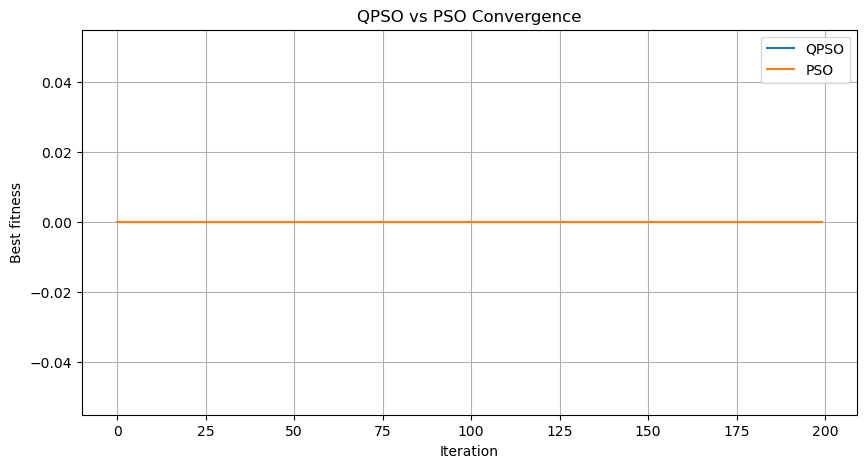

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    convergence,
    label="QPSO"
)

plt.plot(
    pso_convergence,
    label="PSO"
)

plt.xlabel("Iteration")
plt.ylabel("Best fitness")
plt.title("QPSO vs PSO Convergence")
plt.legend()
plt.grid(True)

plt.show()

In [100]:
qpso_zero = next(
    (i for i, x in enumerate(convergence) if x == 0.0),
    None
)

pso_zero = next(
    (i for i, x in enumerate(pso_convergence) if x == 0.0),
    None
)

print("QPSO first reached 0.0:", qpso_zero)
print("PSO first reached 0.0:", pso_zero)

QPSO first reached 0.0: 0
PSO first reached 0.0: 0


In [101]:
final_pso_result = evaluate_particles_fixed(
    [pso_gbest_position],
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)[0]

print("FINAL PSO RESULT")
print("Fitness:", final_pso_result["fitness"])
print("Raw metrics:", final_pso_result["solution"])

print("\nRoutes:")
for i, route in enumerate(final_pso_result["routes"], start=1):
    print(f"Vehicle {i}: {route}")

FINAL PSO RESULT
Fitness: 0.0
Raw metrics: {'distance': 11906.016695749568, 'travel_time': 1758.7242942644955, 'congestion': 158.5, 'emissions': 11906.016695749568, 'vehicle_results': [{'vehicle': 1, 'distance': 2357.934053130146, 'travel_time': 357.9365662869896, 'congestion': 28.4, 'emissions': 2357.934053130146}, {'vehicle': 2, 'distance': 1056.8492502793165, 'travel_time': 159.44074831570157, 'congestion': 17.499999999999996, 'emissions': 1056.8492502793165}, {'vehicle': 3, 'distance': 3379.169703724667, 'travel_time': 418.5139091722572, 'congestion': 53.20000000000001, 'emissions': 3379.169703724667}, {'vehicle': 4, 'distance': 1519.2040921214214, 'travel_time': 226.61352161751432, 'congestion': 41.400000000000006, 'emissions': 1519.2040921214214}, {'vehicle': 5, 'distance': 3592.859596494017, 'travel_time': 596.2195488720329, 'congestion': 18.0, 'emissions': 3592.859596494017}]}

Routes:
Vehicle 1: ['2228165651']
Vehicle 2: ['2473502259', '12183357600']
Vehicle 3: ['443252894', '

In [102]:
# Independent reference particles for normalization
# Implementation choice: separate reference set
# so the optimization swarm does not define its own fitness scale.

np.random.seed(123)

reference_particles = np.random.rand(
    100,
    n_dimensions
)

reference_evaluated = evaluate_particles(
    reference_particles,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node
)

reference_solutions = [
    result["solution"]
    for result in reference_evaluated
]

reference_bounds = {}

for objective in [
    "travel_time",
    "distance",
    "congestion",
    "emissions"
]:

    values = np.array([
        solution[objective]
        for solution in reference_solutions
    ])

    reference_bounds[objective] = {
        "min": float(np.min(values)),
        "max": float(np.max(values))
    }

print("Independent reference bounds:")

for objective in reference_bounds:
    print(
        f"{objective}: "
        f"min={reference_bounds[objective]['min']:.3f}, "
        f"max={reference_bounds[objective]['max']:.3f}"
    )

Independent reference bounds:
travel_time: min=1678.860, max=1963.937
distance: min=11581.923, max=13465.127
congestion: min=155.400, max=188.600
emissions: min=11581.923, max=13465.127


In [103]:
# ============================================================
# CORRECTED QPSO vs PSO EXPERIMENT
# Uses independent normalization reference bounds
# Same initial swarm, same problem, same 200 iterations
# ============================================================

n_iterations = 200
beta_max = 1.0
beta_min = 0.5

# ------------------------------------------------------------
# 1. QPSO
# ------------------------------------------------------------

np.random.seed(42)

qpso_positions = np.random.rand(
    n_particles,
    n_dimensions
)

qpso_pbest_positions = qpso_positions.copy()

qpso_initial_eval = evaluate_particles_fixed(
    qpso_positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)

qpso_pbest_fitness = np.array([
    result["fitness"]
    for result in qpso_initial_eval
])

qpso_best_index = np.argmin(qpso_pbest_fitness)

qpso_gbest_position = (
    qpso_pbest_positions[qpso_best_index].copy()
)

qpso_gbest_fitness = (
    qpso_pbest_fitness[qpso_best_index]
)

qpso_convergence = [
    qpso_gbest_fitness
]


for iteration in range(n_iterations):

    beta = beta_max - (
        (beta_max - beta_min)
        * iteration
        / (n_iterations - 1)
    )

    mbest = np.mean(
        qpso_pbest_positions,
        axis=0
    )

    new_positions = qpso_position_update(
        positions=qpso_positions,
        pbest_positions=qpso_pbest_positions,
        gbest_position=qpso_gbest_position,
        mbest=mbest,
        beta=beta
    )

    evaluated = evaluate_particles_fixed(
        new_positions,
        destinations,
        n_vehicles,
        G_traffic,
        depot_node,
        reference_bounds
    )

    new_fitness = np.array([
        result["fitness"]
        for result in evaluated
    ])

    improved = (
        new_fitness < qpso_pbest_fitness
    )

    qpso_pbest_positions[improved] = (
        new_positions[improved]
    )

    qpso_pbest_fitness[improved] = (
        new_fitness[improved]
    )

    best_index = np.argmin(
        qpso_pbest_fitness
    )

    if (
        qpso_pbest_fitness[best_index]
        < qpso_gbest_fitness
    ):
        qpso_gbest_fitness = (
            qpso_pbest_fitness[best_index]
        )

        qpso_gbest_position = (
            qpso_pbest_positions[best_index].copy()
        )

    qpso_positions = new_positions.copy()

    qpso_convergence.append(
        qpso_gbest_fitness
    )


# ------------------------------------------------------------
# 2. Classical PSO
# ------------------------------------------------------------

np.random.seed(42)

pso_positions = np.random.rand(
    n_particles,
    n_dimensions
)

pso_velocities = np.zeros_like(
    pso_positions
)

pso_initial_eval = evaluate_particles_fixed(
    pso_positions,
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)

pso_pbest_positions = pso_positions.copy()

pso_pbest_fitness = np.array([
    result["fitness"]
    for result in pso_initial_eval
])

pso_best_index = np.argmin(
    pso_pbest_fitness
)

pso_gbest_position = (
    pso_pbest_positions[pso_best_index].copy()
)

pso_gbest_fitness = (
    pso_pbest_fitness[pso_best_index]
)

pso_convergence = [
    pso_gbest_fitness
]


inertia = 0.7
c1 = 1.5
c2 = 1.5


for iteration in range(n_iterations):

    (
        new_positions,
        pso_velocities
    ) = pso_position_update(
        positions=pso_positions,
        velocities=pso_velocities,
        pbest_positions=pso_pbest_positions,
        gbest_position=pso_gbest_position,
        inertia=inertia,
        c1=c1,
        c2=c2
    )

    evaluated = evaluate_particles_fixed(
        new_positions,
        destinations,
        n_vehicles,
        G_traffic,
        depot_node,
        reference_bounds
    )

    new_fitness = np.array([
        result["fitness"]
        for result in evaluated
    ])

    improved = (
        new_fitness < pso_pbest_fitness
    )

    pso_pbest_positions[improved] = (
        new_positions[improved]
    )

    pso_pbest_fitness[improved] = (
        new_fitness[improved]
    )

    best_index = np.argmin(
        pso_pbest_fitness
    )

    if (
        pso_pbest_fitness[best_index]
        < pso_gbest_fitness
    ):
        pso_gbest_fitness = (
            pso_pbest_fitness[best_index]
        )

        pso_gbest_position = (
            pso_pbest_positions[best_index].copy()
        )

    pso_positions = new_positions.copy()

    pso_convergence.append(
        pso_gbest_fitness
    )


# ------------------------------------------------------------
# 3. Results
# ------------------------------------------------------------

print("========== CORRECTED EXPERIMENT ==========")

print("\nQPSO")
print("Initial fitness:", qpso_convergence[0])
print("Final fitness:", qpso_gbest_fitness)

print("\nPSO")
print("Initial fitness:", pso_convergence[0])
print("Final fitness:", pso_gbest_fitness)

print("\nIterations:", n_iterations)

========== CORRECTED EXPERIMENT ==========

QPSO
Initial fitness: 0.19957299642409937
Final fitness: 0.0

PSO
Initial fitness: 0.19957299642409937
Final fitness: 0.0

Iterations: 200


In [104]:
qpso_zero_iteration = next(
    (i for i, x in enumerate(qpso_convergence) if x <= 1e-12),
    None
)

pso_zero_iteration = next(
    (i for i, x in enumerate(pso_convergence) if x <= 1e-12),
    None
)

print("QPSO first reached 0:", qpso_zero_iteration)
print("PSO first reached 0:", pso_zero_iteration)

print("\nQPSO fitness:")
print("Iteration 0:", qpso_convergence[0])
print("Iteration 10:", qpso_convergence[min(10, len(qpso_convergence)-1)])
print("Iteration 25:", qpso_convergence[min(25, len(qpso_convergence)-1)])
print("Iteration 50:", qpso_convergence[min(50, len(qpso_convergence)-1)])
print("Iteration 100:", qpso_convergence[min(100, len(qpso_convergence)-1)])
print("Iteration 200:", qpso_convergence[-1])

print("\nPSO fitness:")
print("Iteration 0:", pso_convergence[0])
print("Iteration 10:", pso_convergence[min(10, len(pso_convergence)-1)])
print("Iteration 25:", pso_convergence[min(25, len(pso_convergence)-1)])
print("Iteration 50:", pso_convergence[min(50, len(pso_convergence)-1)])
print("Iteration 100:", pso_convergence[min(100, len(pso_convergence)-1)])
print("Iteration 200:", pso_convergence[-1])

QPSO first reached 0: 5
PSO first reached 0: 2

QPSO fitness:
Iteration 0: 0.19957299642409937
Iteration 10: 0.0
Iteration 25: 0.0
Iteration 50: 0.0
Iteration 100: 0.0
Iteration 200: 0.0

PSO fitness:
Iteration 0: 0.19957299642409937
Iteration 10: 0.0
Iteration 25: 0.0
Iteration 50: 0.0
Iteration 100: 0.0
Iteration 200: 0.0


In [105]:
# Inspect the final QPSO solution against the independent bounds

final_solution = final_qpso_result["solution"]

print("FINAL QPSO OBJECTIVES")
print()

for objective in [
    "travel_time",
    "distance",
    "congestion",
    "emissions"
]:
    
    value = final_solution[objective]
    min_value = reference_bounds[objective]["min"]
    max_value = reference_bounds[objective]["max"]

    raw_normalized = (
        (value - min_value)
        / (max_value - min_value)
    )

    clipped_normalized = np.clip(
        raw_normalized,
        0.0,
        1.0
    )

    print(objective)
    print("  value      :", value)
    print("  ref min    :", min_value)
    print("  ref max    :", max_value)
    print("  raw norm   :", raw_normalized)
    print("  clipped    :", clipped_normalized)
    print()

FINAL QPSO OBJECTIVES

travel_time
  value      : 1758.7242942644955
  ref min    : 1678.8604271553932
  ref max    : 1963.9368767527903
  raw norm   : 0.2801489467891546
  clipped    : 0.2801489467891546

distance
  value      : 11906.016695749568
  ref min    : 11581.923459405927
  ref max    : 13465.126641917373
  raw norm   : 0.17209679728314212
  clipped    : 0.17209679728314212

congestion
  value      : 158.5
  ref min    : 155.4
  ref max    : 188.60000000000002
  raw norm   : 0.0933734939759034
  clipped    : 0.0933734939759034

emissions
  value      : 11906.016695749568
  ref min    : 11581.923459405927
  ref max    : 13465.126641917373
  raw norm   : 0.17209679728314212
  clipped    : 0.17209679728314212



In [106]:
# Re-evaluate the CURRENT QPSO global best
# using the CURRENT independent reference bounds.

current_qpso_result = evaluate_particles_fixed(
    [qpso_gbest_position],
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)[0]

print("CURRENT QPSO RESULT")
print("Fitness:", current_qpso_result["fitness"])

print("\nNormalized objectives:")
for objective, value in current_qpso_result["normalized"].items():
    print(f"{objective}: {value:.6f}")

print("\nRaw metrics:")
print(current_qpso_result["solution"])

print("\nRoutes:")
for i, route in enumerate(
    current_qpso_result["routes"],
    start=1
):
    print(f"Vehicle {i}: {route}")

CURRENT QPSO RESULT
Fitness: 0.0

Normalized objectives:
travel_time: 0.000000
distance: 0.000000
congestion: 0.000000
emissions: 0.000000

Raw metrics:
{'distance': 11397.338308062754, 'travel_time': 1664.0581891060704, 'congestion': 153.60000000000002, 'emissions': 11397.338308062754, 'vehicle_results': [{'vehicle': 1, 'distance': 1015.9568185371713, 'travel_time': 155.98575564538913, 'congestion': 28.2, 'emissions': 1015.9568185371713}, {'vehicle': 2, 'distance': 4439.257663502586, 'travel_time': 740.8580591384116, 'congestion': 32.8, 'emissions': 4439.257663502586}, {'vehicle': 3, 'distance': 4422.919733901575, 'travel_time': 540.6008527047552, 'congestion': 51.20000000000001, 'emissions': 4422.919733901575}, {'vehicle': 4, 'distance': 1519.2040921214214, 'travel_time': 226.61352161751432, 'congestion': 41.400000000000006, 'emissions': 1519.2040921214214}, {'vehicle': 5, 'distance': 0.0, 'travel_time': 0.0, 'congestion': 0.0, 'emissions': 0.0}]}

Routes:
Vehicle 1: ['2227895766', '

In [107]:
current_pso_result = evaluate_particles_fixed(
    [pso_gbest_position],
    destinations,
    n_vehicles,
    G_traffic,
    depot_node,
    reference_bounds
)[0]

print("CURRENT PSO RESULT")
print("Fitness:", current_pso_result["fitness"])

print("\nNormalized objectives:")
for objective, value in current_pso_result["normalized"].items():
    print(f"{objective}: {value:.6f}")

print("\nRaw metrics:")
print(current_pso_result["solution"])

print("\nRoutes:")
for i, route in enumerate(
    current_pso_result["routes"],
    start=1
):
    print(f"Vehicle {i}: {route}")

CURRENT PSO RESULT
Fitness: 0.0

Normalized objectives:
travel_time: 0.000000
distance: 0.000000
congestion: 0.000000
emissions: 0.000000

Raw metrics:
{'distance': 11019.954640738659, 'travel_time': 1595.1137758948662, 'congestion': 149.00000000000003, 'emissions': 11019.954640738659, 'vehicle_results': [{'vehicle': 1, 'distance': 0.0, 'travel_time': 0.0, 'congestion': 0.0, 'emissions': 0.0}, {'vehicle': 2, 'distance': 4422.919733901575, 'travel_time': 540.6008527047552, 'congestion': 51.20000000000001, 'emissions': 4422.919733901575}, {'vehicle': 3, 'distance': 1484.9712182216447, 'travel_time': 231.6798527005642, 'congestion': 38.400000000000006, 'emissions': 1484.9712182216447}, {'vehicle': 4, 'distance': 5112.06368861544, 'travel_time': 822.8330704895468, 'congestion': 59.400000000000006, 'emissions': 5112.06368861544}, {'vehicle': 5, 'distance': 0.0, 'travel_time': 0.0, 'congestion': 0.0, 'emissions': 0.0}]}

Routes:
Vehicle 1: []
Vehicle 2: ['2228165651', '443252894']
Vehicle 3:

INDEPENDENT REFERENCE BOUNDS
travel_time     min = 1725.861 max = 1963.937
distance        min = 11836.368 max = 13465.127
congestion      min = 158.100 max = 188.600
emissions       min = 11836.368 max = 13465.127

RUNNING QPSO
Seed  1 -> 0.000000
Seed  2 -> 0.000000
Seed  3 -> 0.000000
Seed  4 -> 0.000000
Seed  5 -> 0.000000
Seed  6 -> 0.000000
Seed  7 -> 0.000000
Seed  8 -> 0.000000
Seed  9 -> 0.000000
Seed 10 -> 0.000000

RUNNING PSO
Seed  1 -> 0.000000
Seed  2 -> 0.000000
Seed  3 -> 0.000000
Seed  4 -> 0.000000
Seed  5 -> 0.000000
Seed  6 -> 0.000000
Seed  7 -> 0.000000
Seed  8 -> 0.000000
Seed  9 -> 0.000000
Seed 10 -> 0.000000

FINAL COMPARISON
QPSO mean fitness : 0.000000
QPSO std          : 0.000000
PSO mean fitness  : 0.000000
PSO std           : 0.000000

Per-seed comparison
Seed  1: QPSO=0.000000   PSO=0.000000
Seed  2: QPSO=0.000000   PSO=0.000000
Seed  3: QPSO=0.000000   PSO=0.000000
Seed  4: QPSO=0.000000   PSO=0.000000
Seed  5: QPSO=0.000000   PSO=0.000000
Seed  6: QPSO

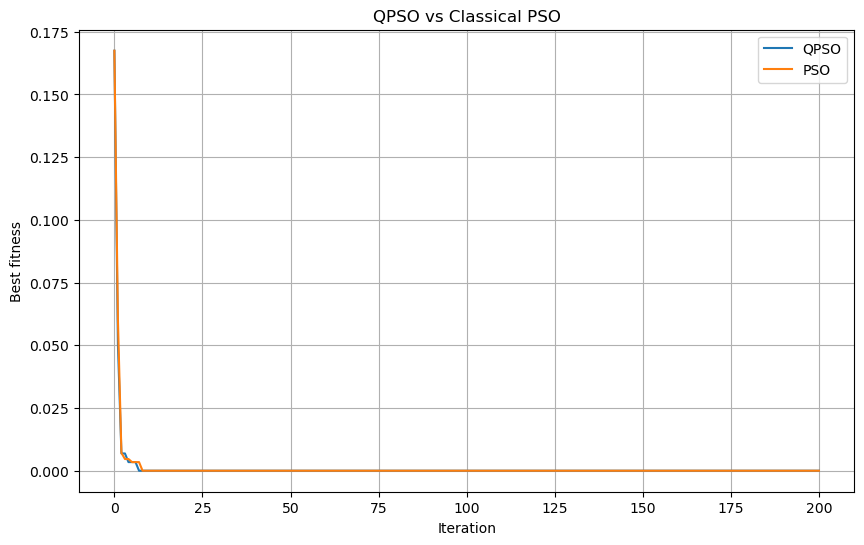


BEST QPSO SOLUTION
Seed: 1
Fitness: 0.0

Routes:
Vehicle 1: ['10053692415', '9189234362']
Vehicle 2: ['1274615185']
Vehicle 3: ['443252894', '2228165651']
Vehicle 4: ['2227895766']
Vehicle 5: ['2473502259', '12183357600']

Metrics:
distance: 11607.789491333502
travel_time: 1678.860427155393
congestion: 156.3
emissions: 11607.789491333502


In [108]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# 1. EXPERIMENT CONFIGURATION
# ============================================================

N_PARTICLES = 25
N_DIMENSIONS = 12
N_VEHICLES = 5
N_ITERATIONS = 200

# PRD QPSO parameter schedule
BETA_MAX = 1.0
BETA_MIN = 0.5

# Classical PSO parameters
# These are implementation choices because the PRD does not
# specify classical PSO parameters.
W = 0.7
C1 = 1.5
C2 = 1.5

OBJECTIVES = [
    "travel_time",
    "distance",
    "congestion",
    "emissions"
]

WEIGHTS = {
    "travel_time": 0.40,
    "distance": 0.30,
    "congestion": 0.20,
    "emissions": 0.10
}


# ============================================================
# 2. DECODER
# ============================================================
# QPSO/PSO positions are unbounded.
# Sigmoid maps them into (0,1).
#
# Sigmoid is monotonic, so the ordering of destination keys
# is preserved.
#
# This is an implementation choice required because the
# random-key decoder needs bounded keys.

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60, 60)))


def decode_particle(particle, destinations, n_vehicles):

    n = len(destinations)

    # Map continuous particle position to valid key range.
    keys = sigmoid(particle)

    # --------------------------------------------------------
    # Destination ordering
    # --------------------------------------------------------

    order_keys = keys[:n]

    sorted_indices = np.argsort(order_keys)

    ordered_destinations = [
        destinations[i]
        for i in sorted_indices
    ]

    # --------------------------------------------------------
    # Vehicle route split
    # --------------------------------------------------------

    split_keys = keys[n:]

    sorted_split_keys = np.sort(split_keys)

    n_splits = n_vehicles - 1

    span = n - n_vehicles + 1

    base_positions = np.arange(
        1,
        n_splits + 1
    )

    split_positions = (
        np.floor(
            sorted_split_keys * span
        ).astype(int)
        + base_positions
    )

    routes = []

    start = 0

    for split in split_positions:

        routes.append(
            ordered_destinations[start:split]
        )

        start = split

    routes.append(
        ordered_destinations[start:]
    )

    return routes


# ============================================================
# 3. ROUTE EVALUATION
# ============================================================

def evaluate_route(route, G, depot):

    if len(route) == 0:

        return {
            "distance": 0.0,
            "travel_time": 0.0,
            "congestion": 0.0,
            "emissions": 0.0
        }

    full_route = [depot] + route + [depot]

    total_distance = 0.0
    total_time = 0.0
    total_congestion = 0.0
    total_emissions = 0.0

    # PRD gives an emissions proxy involving
    # edge_distance × vehicle_weight_factor.
    #
    # The PRD does not specify actual vehicle-specific
    # weight factors, so 1.0 is retained as the
    # temporary implementation value.

    vehicle_weight_factor = 1.0

    for i in range(len(full_route) - 1):

        source = full_route[i]
        target = full_route[i + 1]

        path = nx.shortest_path(
            G,
            source=source,
            target=target,
            weight="traffic_weight"
        )

        for u, v in zip(
            path[:-1],
            path[1:]
        ):

            edge_data = G.get_edge_data(u, v)

            best_edge = min(
                edge_data.values(),
                key=lambda x: float(
                    x["traffic_weight"]
                )
            )

            distance = float(
                best_edge["length"]
            )

            traffic_factor = float(
                best_edge["traffic_factor"]
            )

            traffic_time = float(
                best_edge["traffic_weight"]
            )

            total_distance += distance

            total_time += traffic_time

            total_congestion += traffic_factor

            total_emissions += (
                distance *
                vehicle_weight_factor
            )

    return {
        "distance": total_distance,
        "travel_time": total_time,
        "congestion": total_congestion,
        "emissions": total_emissions
    }


def evaluate_solution(
    routes,
    G,
    depot
):

    total_distance = 0.0
    total_time = 0.0
    total_congestion = 0.0
    total_emissions = 0.0

    vehicle_results = []

    for vehicle_id, route in enumerate(
        routes,
        start=1
    ):

        result = evaluate_route(
            route,
            G,
            depot
        )

        vehicle_results.append({
            "vehicle": vehicle_id,
            "distance": result["distance"],
            "travel_time": result["travel_time"],
            "congestion": result["congestion"],
            "emissions": result["emissions"]
        })

        total_distance += result["distance"]
        total_time += result["travel_time"]
        total_congestion += result["congestion"]
        total_emissions += result["emissions"]

    return {
        "distance": total_distance,
        "travel_time": total_time,
        "congestion": total_congestion,
        "emissions": total_emissions,
        "vehicle_results": vehicle_results
    }


# ============================================================
# 4. BUILD INDEPENDENT NORMALIZATION REFERENCE
# ============================================================
# IMPORTANT:
#
# These bounds are NOT taken from QPSO or PSO.
#
# They come from an independent random reference population.
#
# Therefore neither algorithm determines its own normalization.

np.random.seed(123)

REFERENCE_PARTICLES = np.random.rand(
    100,
    N_DIMENSIONS
)

reference_solutions = []

for particle in REFERENCE_PARTICLES:

    routes = decode_particle(
        particle,
        destinations,
        N_VEHICLES
    )

    routes_graph = [
        [
            str(index_to_node[str(node)])
            for node in route
        ]
        for route in routes
    ]

    solution = evaluate_solution(
        routes_graph,
        G_traffic,
        depot_node
    )

    reference_solutions.append(
        solution
    )


reference_bounds = {}

for objective in OBJECTIVES:

    values = np.array([
        solution[objective]
        for solution in reference_solutions
    ])

    reference_bounds[objective] = {
        "min": float(np.min(values)),
        "max": float(np.max(values))
    }


print("INDEPENDENT REFERENCE BOUNDS")
print("=" * 50)

for objective in OBJECTIVES:

    print(
        f"{objective:15s}"
        f" min = {reference_bounds[objective]['min']:.3f}"
        f" max = {reference_bounds[objective]['max']:.3f}"
    )


# ============================================================
# 5. FITNESS
# ============================================================

def calculate_fitness(
    solution,
    reference_bounds
):

    fitness = 0.0

    for objective in OBJECTIVES:

        value = solution[objective]

        min_value = reference_bounds[
            objective
        ]["min"]

        max_value = reference_bounds[
            objective
        ]["max"]

        if max_value == min_value:

            normalized = 0.0

        else:

            normalized = (
                (value - min_value)
                /
                (max_value - min_value)
            )

        normalized = np.clip(
            normalized,
            0.0,
            1.0
        )

        fitness += (
            WEIGHTS[objective]
            *
            normalized
        )

    return float(fitness)


def evaluate_particle(
    particle
):

    routes = decode_particle(
        particle,
        destinations,
        N_VEHICLES
    )

    routes_graph = [
        [
            str(index_to_node[str(node)])
            for node in route
        ]
        for route in routes
    ]

    solution = evaluate_solution(
        routes_graph,
        G_traffic,
        depot_node
    )

    fitness = calculate_fitness(
        solution,
        reference_bounds
    )

    return {
        "fitness": fitness,
        "solution": solution,
        "routes": routes_graph
    }


# ============================================================
# 6. QPSO
# ============================================================

def qpso_update(
    positions,
    pbest_positions,
    gbest_position,
    mbest,
    beta
):

    n_particles, n_dimensions = (
        positions.shape
    )

    phi = np.random.rand(
        n_particles,
        n_dimensions
    )

    # Local attractor
    p = (
        phi * pbest_positions
        +
        (1.0 - phi) * gbest_position
    )

    u = np.random.rand(
        n_particles,
        n_dimensions
    )

    u = np.clip(
        u,
        1e-12,
        1.0
    )

    direction = np.where(
        np.random.rand(
            n_particles,
            n_dimensions
        ) < 0.5,
        -1.0,
        1.0
    )

    new_positions = (
        p
        +
        direction
        * beta
        * np.abs(
            mbest - positions
        )
        * np.log(1.0 / u)
    )

    return new_positions


def run_qpso(seed):

    np.random.seed(seed)

    positions = np.random.uniform(
        -1.0,
        1.0,
        (
            N_PARTICLES,
            N_DIMENSIONS
        )
    )

    evaluations = [
        evaluate_particle(p)
        for p in positions
    ]

    fitness = np.array([
        e["fitness"]
        for e in evaluations
    ])

    pbest_positions = positions.copy()

    pbest_fitness = fitness.copy()

    best_index = np.argmin(
        pbest_fitness
    )

    gbest_position = (
        pbest_positions[
            best_index
        ].copy()
    )

    gbest_fitness = (
        pbest_fitness[
            best_index
        ]
    )

    convergence = [
        gbest_fitness
    ]

    for iteration in range(
        N_ITERATIONS
    ):

        # Mean best position
        mbest = np.mean(
            pbest_positions,
            axis=0
        )

        # PRD beta schedule:
        # beta = 1.0 -> 0.5

        beta = (
            BETA_MAX
            -
            (
                BETA_MAX
                -
                BETA_MIN
            )
            *
            iteration
            /
            (
                N_ITERATIONS - 1
            )
        )

        positions = qpso_update(
            positions,
            pbest_positions,
            gbest_position,
            mbest,
            beta
        )

        evaluations = [
            evaluate_particle(p)
            for p in positions
        ]

        fitness = np.array([
            e["fitness"]
            for e in evaluations
        ])

        # Personal best update

        improved = (
            fitness
            <
            pbest_fitness
        )

        pbest_positions[
            improved
        ] = positions[
            improved
        ]

        pbest_fitness[
            improved
        ] = fitness[
            improved
        ]

        # Global best update

        best_index = np.argmin(
            pbest_fitness
        )

        if (
            pbest_fitness[
                best_index
            ]
            <
            gbest_fitness
        ):

            gbest_fitness = (
                pbest_fitness[
                    best_index
                ]
            )

            gbest_position = (
                pbest_positions[
                    best_index
                ].copy()
            )

        convergence.append(
            gbest_fitness
        )

    final_result = evaluate_particle(
        gbest_position
    )

    return {
        "best_fitness": gbest_fitness,
        "best_position": gbest_position,
        "convergence": convergence,
        "result": final_result
    }


# ============================================================
# 7. CLASSICAL PSO
# ============================================================

def pso_update(
    positions,
    velocities,
    pbest_positions,
    gbest_position
):

    r1 = np.random.rand(
        *positions.shape
    )

    r2 = np.random.rand(
        *positions.shape
    )

    velocities = (
        W * velocities
        +
        C1
        * r1
        * (
            pbest_positions
            -
            positions
        )
        +
        C2
        * r2
        * (
            gbest_position
            -
            positions
        )
    )

    positions = (
        positions
        +
        velocities
    )

    return positions, velocities


def run_pso(seed):

    np.random.seed(seed)

    positions = np.random.uniform(
        -1.0,
        1.0,
        (
            N_PARTICLES,
            N_DIMENSIONS
        )
    )

    velocities = np.random.uniform(
        -0.1,
        0.1,
        (
            N_PARTICLES,
            N_DIMENSIONS
        )
    )

    evaluations = [
        evaluate_particle(p)
        for p in positions
    ]

    fitness = np.array([
        e["fitness"]
        for e in evaluations
    ])

    pbest_positions = positions.copy()

    pbest_fitness = fitness.copy()

    best_index = np.argmin(
        pbest_fitness
    )

    gbest_position = (
        pbest_positions[
            best_index
        ].copy()
    )

    gbest_fitness = (
        pbest_fitness[
            best_index
        ]
    )

    convergence = [
        gbest_fitness
    ]

    for iteration in range(
        N_ITERATIONS
    ):

        positions, velocities = (
            pso_update(
                positions,
                velocities,
                pbest_positions,
                gbest_position
            )
        )

        evaluations = [
            evaluate_particle(p)
            for p in positions
        ]

        fitness = np.array([
            e["fitness"]
            for e in evaluations
        ])

        improved = (
            fitness
            <
            pbest_fitness
        )

        pbest_positions[
            improved
        ] = positions[
            improved
        ]

        pbest_fitness[
            improved
        ] = fitness[
            improved
        ]

        best_index = np.argmin(
            pbest_fitness
        )

        if (
            pbest_fitness[
                best_index
            ]
            <
            gbest_fitness
        ):

            gbest_fitness = (
                pbest_fitness[
                    best_index
                ]
            )

            gbest_position = (
                pbest_positions[
                    best_index
                ].copy()
            )

        convergence.append(
            gbest_fitness
        )

    final_result = evaluate_particle(
        gbest_position
    )

    return {
        "best_fitness": gbest_fitness,
        "best_position": gbest_position,
        "convergence": convergence,
        "result": final_result
    }


# ============================================================
# 8. SAME SEEDS FOR BOTH ALGORITHMS
# ============================================================

SEEDS = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]

qpso_results = []
pso_results = []

print("\nRUNNING QPSO")
print("=" * 50)

for seed in SEEDS:

    result = run_qpso(seed)

    qpso_results.append(result)

    print(
        f"Seed {seed:2d} -> "
        f"{result['best_fitness']:.6f}"
    )


print("\nRUNNING PSO")
print("=" * 50)

for seed in SEEDS:

    result = run_pso(seed)

    pso_results.append(result)

    print(
        f"Seed {seed:2d} -> "
        f"{result['best_fitness']:.6f}"
    )


# ============================================================
# 9. STATISTICAL COMPARISON
# ============================================================

qpso_fitness = np.array([
    r["best_fitness"]
    for r in qpso_results
])

pso_fitness = np.array([
    r["best_fitness"]
    for r in pso_results
])


print("\nFINAL COMPARISON")
print("=" * 50)

print(
    f"QPSO mean fitness : "
    f"{np.mean(qpso_fitness):.6f}"
)

print(
    f"QPSO std          : "
    f"{np.std(qpso_fitness):.6f}"
)

print(
    f"PSO mean fitness  : "
    f"{np.mean(pso_fitness):.6f}"
)

print(
    f"PSO std           : "
    f"{np.std(pso_fitness):.6f}"
)


print("\nPer-seed comparison")
print("=" * 50)

for i, seed in enumerate(SEEDS):

    print(
        f"Seed {seed:2d}: "
        f"QPSO={qpso_fitness[i]:.6f}   "
        f"PSO={pso_fitness[i]:.6f}"
    )


# ============================================================
# 10. CONVERGENCE CURVES
# ============================================================

qpso_mean_curve = np.mean(
    np.array([
        r["convergence"]
        for r in qpso_results
    ]),
    axis=0
)

pso_mean_curve = np.mean(
    np.array([
        r["convergence"]
        for r in pso_results
    ]),
    axis=0
)


plt.figure(figsize=(10, 6))

plt.plot(
    qpso_mean_curve,
    label="QPSO"
)

plt.plot(
    pso_mean_curve,
    label="PSO"
)

plt.xlabel("Iteration")

plt.ylabel(
    "Best fitness"
)

plt.title(
    "QPSO vs Classical PSO"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 11. BEST QPSO SOLUTION DETAILS
# ============================================================

best_qpso_index = np.argmin(
    qpso_fitness
)

best_qpso = qpso_results[
    best_qpso_index
]

print("\nBEST QPSO SOLUTION")
print("=" * 50)

print(
    "Seed:",
    SEEDS[best_qpso_index]
)

print(
    "Fitness:",
    best_qpso["best_fitness"]
)

print(
    "\nRoutes:"
)

for i, route in enumerate(
    best_qpso["result"]["routes"],
    start=1
):

    print(
        f"Vehicle {i}: {route}"
    )

print(
    "\nMetrics:"
)

for key, value in (
    best_qpso[
        "result"
    ]["solution"].items()
):

    if key != "vehicle_results":

        print(
            f"{key}: {value}"
        )

In [109]:
# ============================================================
# FIXED NORMALIZATION BOUNDS
# ============================================================
#
# The PRD requires each objective to be normalized to [0,1].
# It does not specify the normalization-bound construction.
#
# Implementation choice:
# We derive conservative upper bounds from the graph itself.
#
# The bounds are computed ONCE, before QPSO/PSO.
# Therefore neither algorithm influences its own normalization.
#
# Lower bound = 0
#
# Upper bound:
# A feasible solution has 8 destinations and at most 5 non-empty
# vehicle routes.
#
# Therefore the total number of route legs is at most:
#
#     8 destination visits + 5 returns to depot = 13 legs
#
# We calculate the maximum metric of a traffic-aware shortest
# path between any pair of graph nodes, then multiply by 13.
# ============================================================

print("Computing fixed normalization bounds...")
print("This may take a little time on the 800-node graph.\n")


# ------------------------------------------------------------
# Store maximum pairwise path metrics
# ------------------------------------------------------------

max_pair_distance = 0.0
max_pair_time = 0.0
max_pair_congestion = 0.0
max_pair_emissions = 0.0


nodes = list(G_traffic.nodes())

total_nodes = len(nodes)


for counter, source in enumerate(nodes):

    # Traffic-aware shortest paths
    paths = nx.single_source_dijkstra_path(
        G_traffic,
        source,
        weight="traffic_weight"
    )

    for target, path in paths.items():

        if source == target:
            continue

        pair_distance = 0.0
        pair_time = 0.0
        pair_congestion = 0.0

        for u, v in zip(
            path[:-1],
            path[1:]
        ):

            edge_data = G_traffic.get_edge_data(u, v)

            best_edge = min(
                edge_data.values(),
                key=lambda x: float(
                    x["traffic_weight"]
                )
            )

            distance = float(
                best_edge["length"]
            )

            traffic_time = float(
                best_edge["traffic_weight"]
            )

            traffic_factor = float(
                best_edge["traffic_factor"]
            )

            pair_distance += distance
            pair_time += traffic_time
            pair_congestion += traffic_factor

        pair_emissions = pair_distance

        max_pair_distance = max(
            max_pair_distance,
            pair_distance
        )

        max_pair_time = max(
            max_pair_time,
            pair_time
        )

        max_pair_congestion = max(
            max_pair_congestion,
            pair_congestion
        )

        max_pair_emissions = max(
            max_pair_emissions,
            pair_emissions
        )

    if (
        counter + 1
    ) % 100 == 0:

        print(
            f"Processed "
            f"{counter + 1}/{total_nodes} nodes..."
        )


# ------------------------------------------------------------
# Maximum number of route legs
# ------------------------------------------------------------

MAX_ROUTE_LEGS = (
    len(destinations)
    + n_vehicles
)


# ------------------------------------------------------------
# Fixed upper bounds
# ------------------------------------------------------------

fixed_bounds = {

    "travel_time": {
        "min": 0.0,
        "max": (
            MAX_ROUTE_LEGS
            * max_pair_time
        )
    },

    "distance": {
        "min": 0.0,
        "max": (
            MAX_ROUTE_LEGS
            * max_pair_distance
        )
    },

    "congestion": {
        "min": 0.0,
        "max": (
            MAX_ROUTE_LEGS
            * max_pair_congestion
        )
    },

    "emissions": {
        "min": 0.0,
        "max": (
            MAX_ROUTE_LEGS
            * max_pair_emissions
        )
    }
}


print("\nFIXED NORMALIZATION BOUNDS")
print("=" * 60)

for objective in OBJECTIVES:

    print(
        f"{objective:15s}"
        f" min = "
        f"{fixed_bounds[objective]['min']:.3f}"
        f" max = "
        f"{fixed_bounds[objective]['max']:.3f}"
    )

print(
    "\nMaximum route legs:",
    MAX_ROUTE_LEGS
)

Computing fixed normalization bounds...
This may take a little time on the 800-node graph.

Processed 100/800 nodes...
Processed 200/800 nodes...
Processed 300/800 nodes...
Processed 400/800 nodes...
Processed 500/800 nodes...
Processed 600/800 nodes...
Processed 700/800 nodes...
Processed 800/800 nodes...

FIXED NORMALIZATION BOUNDS
travel_time     min = 0.000 max = 10162.597
distance        min = 0.000 max = 70560.959
congestion      min = 0.000 max = 1055.600
emissions       min = 0.000 max = 70560.959

Maximum route legs: 13


In [110]:
# ============================================================
# FIXED [0,1] NORMALIZATION
# ============================================================

def normalize_solution(
    solution,
    fixed_bounds
):

    normalized = {}

    for objective in OBJECTIVES:

        value = float(
            solution[objective]
        )

        min_value = fixed_bounds[
            objective
        ]["min"]

        max_value = fixed_bounds[
            objective
        ]["max"]

        normalized_value = (
            value - min_value
        ) / (
            max_value - min_value
        )

        # Numerical protection only.
        # With conservative bounds, values should already
        # lie inside [0,1].

        normalized_value = np.clip(
            normalized_value,
            0.0,
            1.0
        )

        normalized[objective] = (
            normalized_value
        )

    return normalized


def calculate_fitness(
    solution,
    fixed_bounds
):

    normalized = normalize_solution(
        solution,
        fixed_bounds
    )

    fitness = (

        0.40
        * normalized["travel_time"]

        +

        0.30
        * normalized["distance"]

        +

        0.20
        * normalized["congestion"]

        +

        0.10
        * normalized["emissions"]
    )

    return float(fitness)


def evaluate_particle(
    particle
):

    routes = decode_particle(
        particle,
        destinations,
        N_VEHICLES
    )

    routes_graph = [

        [
            str(
                index_to_node[
                    str(node)
                ]
            )

            for node in route

        ]

        for route in routes
    ]

    solution = evaluate_solution(
        routes_graph,
        G_traffic,
        depot_node
    )

    normalized = normalize_solution(
        solution,
        fixed_bounds
    )

    fitness = calculate_fitness(
        solution,
        fixed_bounds
    )

    return {

        "fitness": fitness,

        "normalized": normalized,

        "solution": solution,

        "routes": routes_graph
    }

RUNNING QPSO
Seed  1: 0.14967633
Seed  2: 0.14967633
Seed  3: 0.14775571
Seed  4: 0.14967633
Seed  5: 0.14775571
Seed  6: 0.14775571
Seed  7: 0.14775571
Seed  8: 0.14775571
Seed  9: 0.14775571
Seed 10: 0.14775571

RUNNING PSO
Seed  1: 0.15728855
Seed  2: 0.15728855
Seed  3: 0.15728855
Seed  4: 0.15920917
Seed  5: 0.15576743
Seed  6: 0.15576743
Seed  7: 0.15728855
Seed  8: 0.15576743
Seed  9: 0.15728855
Seed 10: 0.15576743

FINAL COMPARISON
QPSO mean : 0.14833190
QPSO std  : 0.00088014
PSO mean  : 0.15687216
PSO std   : 0.00105878

PER-SEED RESULTS
Seed  1: QPSO = 0.14967633   PSO = 0.15728855
Seed  2: QPSO = 0.14967633   PSO = 0.15728855
Seed  3: QPSO = 0.14775571   PSO = 0.15728855
Seed  4: QPSO = 0.14967633   PSO = 0.15920917
Seed  5: QPSO = 0.14775571   PSO = 0.15576743
Seed  6: QPSO = 0.14775571   PSO = 0.15576743
Seed  7: QPSO = 0.14775571   PSO = 0.15728855
Seed  8: QPSO = 0.14775571   PSO = 0.15576743
Seed  9: QPSO = 0.14775571   PSO = 0.15728855
Seed 10: QPSO = 0.14775571   PSO

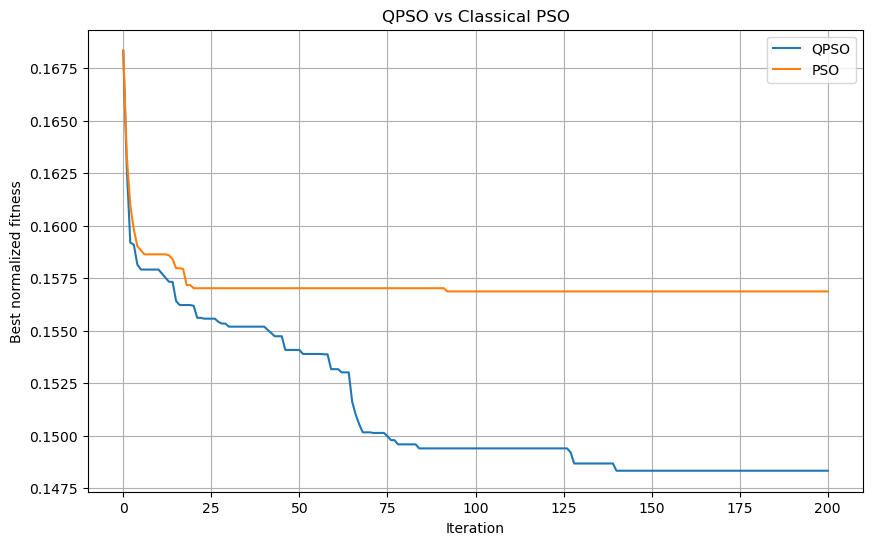

In [111]:
# ============================================================
# FINAL QPSO vs PSO EXPERIMENT
# ============================================================

N_PARTICLES = 25
N_DIMENSIONS = 12
N_VEHICLES = 5
N_ITERATIONS = 200

BETA_MAX = 1.0
BETA_MIN = 0.5

# Classical PSO parameters.
# Implementation choice because PRD does not specify PSO values.

W = 0.7
C1 = 1.5
C2 = 1.5


# ============================================================
# QPSO UPDATE
# ============================================================

def qpso_update(
    positions,
    pbest_positions,
    gbest_position,
    mbest,
    beta
):

    phi = np.random.rand(
        *positions.shape
    )

    # Local attractor
    p = (
        phi * pbest_positions
        +
        (1.0 - phi)
        * gbest_position
    )

    u = np.random.rand(
        *positions.shape
    )

    u = np.clip(
        u,
        1e-12,
        1.0
    )

    direction = np.where(
        np.random.rand(
            *positions.shape
        ) < 0.5,
        -1.0,
        1.0
    )

    new_positions = (
        p
        +
        direction
        * beta
        * np.abs(
            mbest - positions
        )
        * np.log(
            1.0 / u
        )
    )

    return new_positions


# ============================================================
# RUN QPSO
# ============================================================

def run_qpso(seed):

    np.random.seed(seed)

    positions = np.random.uniform(
        -1.0,
        1.0,
        (
            N_PARTICLES,
            N_DIMENSIONS
        )
    )

    evaluations = [
        evaluate_particle(p)
        for p in positions
    ]

    fitness = np.array([
        e["fitness"]
        for e in evaluations
    ])

    pbest_positions = positions.copy()

    pbest_fitness = fitness.copy()

    best_index = np.argmin(
        pbest_fitness
    )

    gbest_position = (
        pbest_positions[
            best_index
        ].copy()
    )

    gbest_fitness = (
        pbest_fitness[
            best_index
        ]
    )

    convergence = [
        gbest_fitness
    ]

    for iteration in range(
        N_ITERATIONS
    ):

        # Mean best
        mbest = np.mean(
            pbest_positions,
            axis=0
        )

        # beta: 1.0 -> 0.5
        beta = (
            BETA_MAX
            -
            (
                BETA_MAX
                -
                BETA_MIN
            )
            *
            iteration
            /
            (N_ITERATIONS - 1)
        )

        positions = qpso_update(
            positions,
            pbest_positions,
            gbest_position,
            mbest,
            beta
        )

        evaluations = [
            evaluate_particle(p)
            for p in positions
        ]

        fitness = np.array([
            e["fitness"]
            for e in evaluations
        ])

        # Personal best
        improved = (
            fitness
            <
            pbest_fitness
        )

        pbest_positions[
            improved
        ] = positions[
            improved
        ]

        pbest_fitness[
            improved
        ] = fitness[
            improved
        ]

        # Global best
        best_index = np.argmin(
            pbest_fitness
        )

        if (
            pbest_fitness[
                best_index
            ]
            <
            gbest_fitness
        ):

            gbest_fitness = (
                pbest_fitness[
                    best_index
                ]
            )

            gbest_position = (
                pbest_positions[
                    best_index
                ].copy()
            )

        convergence.append(
            gbest_fitness
        )

    result = evaluate_particle(
        gbest_position
    )

    return {

        "best_fitness":
            gbest_fitness,

        "best_position":
            gbest_position,

        "convergence":
            convergence,

        "result":
            result
    }


# ============================================================
# PSO UPDATE
# ============================================================

def pso_update(
    positions,
    velocities,
    pbest_positions,
    gbest_position
):

    r1 = np.random.rand(
        *positions.shape
    )

    r2 = np.random.rand(
        *positions.shape
    )

    velocities = (

        W * velocities

        +

        C1
        * r1
        * (
            pbest_positions
            -
            positions
        )

        +

        C2
        * r2
        * (
            gbest_position
            -
            positions
        )
    )

    positions = (
        positions
        +
        velocities
    )

    return positions, velocities


# ============================================================
# RUN PSO
# ============================================================

def run_pso(seed):

    np.random.seed(seed)

    positions = np.random.uniform(
        -1.0,
        1.0,
        (
            N_PARTICLES,
            N_DIMENSIONS
        )
    )

    velocities = np.random.uniform(
        -0.1,
        0.1,
        (
            N_PARTICLES,
            N_DIMENSIONS
        )
    )

    evaluations = [
        evaluate_particle(p)
        for p in positions
    ]

    fitness = np.array([
        e["fitness"]
        for e in evaluations
    ])

    pbest_positions = positions.copy()

    pbest_fitness = fitness.copy()

    best_index = np.argmin(
        pbest_fitness
    )

    gbest_position = (
        pbest_positions[
            best_index
        ].copy()
    )

    gbest_fitness = (
        pbest_fitness[
            best_index
        ]
    )

    convergence = [
        gbest_fitness
    ]

    for iteration in range(
        N_ITERATIONS
    ):

        positions, velocities = (
            pso_update(
                positions,
                velocities,
                pbest_positions,
                gbest_position
            )
        )

        evaluations = [
            evaluate_particle(p)
            for p in positions
        ]

        fitness = np.array([
            e["fitness"]
            for e in evaluations
        ])

        # Personal best
        improved = (
            fitness
            <
            pbest_fitness
        )

        pbest_positions[
            improved
        ] = positions[
            improved
        ]

        pbest_fitness[
            improved
        ] = fitness[
            improved
        ]

        # Global best
        best_index = np.argmin(
            pbest_fitness
        )

        if (
            pbest_fitness[
                best_index
            ]
            <
            gbest_fitness
        ):

            gbest_fitness = (
                pbest_fitness[
                    best_index
                ]
            )

            gbest_position = (
                pbest_positions[
                    best_index
                ].copy()
            )

        convergence.append(
            gbest_fitness
        )

    result = evaluate_particle(
        gbest_position
    )

    return {

        "best_fitness":
            gbest_fitness,

        "best_position":
            gbest_position,

        "convergence":
            convergence,

        "result":
            result
    }


# ============================================================
# SAME SEEDS
# ============================================================

SEEDS = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]


qpso_results = []
pso_results = []


print("RUNNING QPSO")
print("=" * 60)

for seed in SEEDS:

    result = run_qpso(seed)

    qpso_results.append(
        result
    )

    print(
        f"Seed {seed:2d}: "
        f"{result['best_fitness']:.8f}"
    )


print("\nRUNNING PSO")
print("=" * 60)

for seed in SEEDS:

    result = run_pso(seed)

    pso_results.append(
        result
    )

    print(
        f"Seed {seed:2d}: "
        f"{result['best_fitness']:.8f}"
    )


# ============================================================
# STATISTICS
# ============================================================

qpso_fitness = np.array([
    r["best_fitness"]
    for r in qpso_results
])

pso_fitness = np.array([
    r["best_fitness"]
    for r in pso_results
])


print("\nFINAL COMPARISON")
print("=" * 60)

print(
    f"QPSO mean : "
    f"{np.mean(qpso_fitness):.8f}"
)

print(
    f"QPSO std  : "
    f"{np.std(qpso_fitness):.8f}"
)

print(
    f"PSO mean  : "
    f"{np.mean(pso_fitness):.8f}"
)

print(
    f"PSO std   : "
    f"{np.std(pso_fitness):.8f}"
)


print("\nPER-SEED RESULTS")
print("=" * 60)

for i, seed in enumerate(SEEDS):

    print(
        f"Seed {seed:2d}: "
        f"QPSO = {qpso_fitness[i]:.8f}   "
        f"PSO = {pso_fitness[i]:.8f}"
    )


# ============================================================
# MEAN CONVERGENCE
# ============================================================

qpso_curve = np.mean(
    np.array([
        r["convergence"]
        for r in qpso_results
    ]),
    axis=0
)

pso_curve = np.mean(
    np.array([
        r["convergence"]
        for r in pso_results
    ]),
    axis=0
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    qpso_curve,
    label="QPSO"
)

plt.plot(
    pso_curve,
    label="PSO"
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Best normalized fitness"
)

plt.title(
    "QPSO vs Classical PSO"
)

plt.legend()

plt.grid(True)

plt.show()

In [112]:
# ============================================================
# BEST QPSO SOLUTION
# ============================================================

best_qpso_index = np.argmin(
    qpso_fitness
)

best_qpso = qpso_results[
    best_qpso_index
]

print("BEST QPSO SOLUTION")
print("=" * 60)

print(
    "Seed:",
    SEEDS[best_qpso_index]
)

print(
    "Fitness:",
    best_qpso["best_fitness"]
)

print("\nNORMALIZED OBJECTIVES")

for objective, value in (
    best_qpso[
        "result"
    ]["normalized"].items()
):

    print(
        f"{objective:15s}: "
        f"{value:.6f}"
    )

print("\nRAW METRICS")

solution = best_qpso[
    "result"
]["solution"]

for objective in OBJECTIVES:

    print(
        f"{objective:15s}: "
        f"{solution[objective]:.3f}"
    )

print("\nROUTES")

for i, route in enumerate(
    best_qpso[
        "result"
    ]["routes"],
    start=1
):

    print(
        f"Vehicle {i}: {route}"
    )

BEST QPSO SOLUTION
Seed: 3
Fitness: 0.14775570886307507

NORMALIZED OBJECTIVES
travel_time    : 0.152303
distance       : 0.149826
congestion     : 0.134521
emissions      : 0.149826

RAW METRICS
travel_time    : 1547.794
distance       : 10571.862
congestion     : 142.000
emissions      : 10571.862

ROUTES
Vehicle 1: ['1274615185']
Vehicle 2: ['2473502259']
Vehicle 3: ['2228165651', '443252894', '12183357600', '2227895766']
Vehicle 4: ['10053692415', '9189234362']
Vehicle 5: []


In [113]:
# ============================================================
# STEP 1 — CURRENT M1 EXPERIMENT CONFIGURATION
# ============================================================

print("M1 QPSO SCALABILITY TEST")
print("=" * 60)

print("Graph nodes       :", G_traffic.number_of_nodes())
print("Graph edges       :", G_traffic.number_of_edges())
print("Vehicles          :", N_VEHICLES)
print("Destinations      :", len(destinations))
print("Particles         :", N_PARTICLES)
print("Iterations        :", N_ITERATIONS)

print("\nDepot:")
print(depot_node)

print("\nDestinations:")
print(destinations)

print("\nTraffic factor range:")

traffic_factors = []

for u, v, key, data in G_traffic.edges(
    keys=True,
    data=True
):
    traffic_factors.append(
        float(data["traffic_factor"])
    )

print(
    "Min :", min(traffic_factors)
)

print(
    "Max :", max(traffic_factors)
)

print(
    "Mean:",
    np.mean(traffic_factors)
)

print("\nGraph connected:",
      nx.is_connected(G_traffic))

M1 QPSO SCALABILITY TEST
Graph nodes       : 800
Graph edges       : 1056
Vehicles          : 5
Destinations      : 8
Particles         : 25
Iterations        : 200

Depot:
4294224252

Destinations:
[613, 684, 519, 348, 557, 68, 344, 70]

Traffic factor range:
Min : 1.0
Max : 2.0
Mean: 1.499621212121212

Graph connected: True


In [114]:
# ============================================================
# STEP 2 — QPSO SCALABILITY / RUNTIME TEST
# ============================================================

import time

print("QPSO SCALABILITY TEST")
print("=" * 60)

scalability_seed = 42

start_time = time.perf_counter()

scalability_result = run_qpso(
    scalability_seed
)

end_time = time.perf_counter()

runtime_seconds = (
    end_time - start_time
)

print("\nRESULT")
print("=" * 60)

print(
    f"Graph nodes       : "
    f"{G_traffic.number_of_nodes()}"
)

print(
    f"Graph edges       : "
    f"{G_traffic.number_of_edges()}"
)

print(
    f"Vehicles          : "
    f"{N_VEHICLES}"
)

print(
    f"Destinations      : "
    f"{len(destinations)}"
)

print(
    f"Particles         : "
    f"{N_PARTICLES}"
)

print(
    f"Iterations        : "
    f"{N_ITERATIONS}"
)

print(
    f"Runtime           : "
    f"{runtime_seconds:.3f} seconds"
)

print(
    f"Best fitness      : "
    f"{scalability_result['best_fitness']:.8f}"
)

print("\nBEST ROUTES")

for i, route in enumerate(
    scalability_result["result"]["routes"],
    start=1
):

    print(
        f"Vehicle {i}: {route}"
    )

QPSO SCALABILITY TEST

RESULT
Graph nodes       : 800
Graph edges       : 1056
Vehicles          : 5
Destinations      : 8
Particles         : 25
Iterations        : 200
Runtime           : 46.193 seconds
Best fitness      : 0.14775571

BEST ROUTES
Vehicle 1: ['1274615185']
Vehicle 2: ['2228165651', '443252894', '12183357600', '2227895766']
Vehicle 3: ['10053692415', '9189234362']
Vehicle 4: ['2473502259']
Vehicle 5: []


In [115]:
# ============================================================
# STEP 3 — TRAFFIC WEIGHT UPDATE TEST
# ============================================================

print("TRAFFIC WEIGHT UPDATE TEST")
print("=" * 60)

# Select a few edges for verification
sample_edges = list(
    G_traffic.edges(
        keys=True,
        data=True
    )
)[:10]

print("\nBEFORE / AFTER TRAFFIC WEIGHT CHECK")
print("=" * 60)

update_errors = []

for u, v, key, data in sample_edges:

    base_time = float(
        data["travel_time"]
    )

    traffic_factor = float(
        data["traffic_factor"]
    )

    expected_weight = (
        base_time
        * traffic_factor
    )

    actual_weight = float(
        data["traffic_weight"]
    )

    error = abs(
        expected_weight
        -
        actual_weight
    )

    update_errors.append(error)

    print(
        f"Edge {u} -> {v}"
    )

    print(
        f"  base travel time : "
        f"{base_time:.4f}"
    )

    print(
        f"  traffic factor   : "
        f"{traffic_factor:.2f}"
    )

    print(
        f"  expected weight  : "
        f"{expected_weight:.4f}"
    )

    print(
        f"  actual weight    : "
        f"{actual_weight:.4f}"
    )

    print(
        f"  error            : "
        f"{error:.10f}"
    )

    print()


print("=" * 60)

if max(update_errors) < 1e-9:

    print(
        "PASS: Traffic weights are "
        "consistent with the current "
        "traffic factors."
    )

else:

    print(
        "CHECK REQUIRED: "
        "Traffic weight mismatch detected."
    )

TRAFFIC WEIGHT UPDATE TEST

BEFORE / AFTER TRAFFIC WEIGHT CHECK
Edge 11387494406 -> 248455238
  base travel time : 4.8875
  traffic factor   : 1.80
  expected weight  : 8.7974
  actual weight    : 8.7974
  error            : 0.0000000000

Edge 1833752585 -> 442972782
  base travel time : 4.8640
  traffic factor   : 2.00
  expected weight  : 9.7279
  actual weight    : 9.7279
  error            : 0.0000000000

Edge 1833752585 -> 3356645008
  base travel time : 4.1392
  traffic factor   : 1.50
  expected weight  : 6.2088
  actual weight    : 6.2088
  error            : 0.0000000000

Edge 1833752585 -> 7088469626
  base travel time : 4.7624
  traffic factor   : 2.00
  expected weight  : 9.5249
  actual weight    : 9.5249
  error            : 0.0000000000

Edge 1833752587 -> 12460929652
  base travel time : 4.4645
  traffic factor   : 2.00
  expected weight  : 8.9289
  actual weight    : 8.9289
  error            : 0.0000000000

Edge 1833752587 -> 13266174883
  base travel time : 2.3271
  

In [116]:
# ============================================================
# STEP 4 — M1 RESULTS SUMMARY
# ============================================================

print()
print("=" * 70)
print("                 M1 — QPSO RESULTS SUMMARY")
print("=" * 70)

print("\n1. QPSO vs CLASSICAL PSO")
print("-" * 70)

print(
    f"QPSO mean fitness : "
    f"{np.mean(qpso_fitness):.6f}"
)

print(
    f"QPSO std          : "
    f"{np.std(qpso_fitness):.6f}"
)

print(
    f"PSO mean fitness  : "
    f"{np.mean(pso_fitness):.6f}"
)

print(
    f"PSO std           : "
    f"{np.std(pso_fitness):.6f}"
)

improvement = (
    (
        np.mean(pso_fitness)
        -
        np.mean(qpso_fitness)
    )
    /
    np.mean(pso_fitness)
) * 100

print(
    f"QPSO improvement  : "
    f"{improvement:.2f}%"
)


print("\n2. SCALABILITY")
print("-" * 70)

print(
    f"Graph nodes       : "
    f"{G_traffic.number_of_nodes()}"
)

print(
    f"Graph edges       : "
    f"{G_traffic.number_of_edges()}"
)

print(
    f"Vehicles          : "
    f"{N_VEHICLES}"
)

print(
    f"Destinations      : "
    f"{len(destinations)}"
)

print(
    f"Particles         : "
    f"{N_PARTICLES}"
)

print(
    f"Iterations        : "
    f"{N_ITERATIONS}"
)

print(
    f"Runtime           : "
    f"{runtime_seconds:.3f} seconds"
)

print(
    f"Best fitness      : "
    f"{scalability_result['best_fitness']:.6f}"
)


print("\n3. TRAFFIC UPDATE")
print("-" * 70)

print(
    "Traffic weight formula:"
)

print(
    "traffic_weight = "
    "travel_time × traffic_factor"
)

print(
    "Maximum validation error:",
    f"{max(update_errors):.10f}"
)


print("\n4. M1 STATUS")
print("-" * 70)

print(
    "QPSO vs PSO validation : COMPLETED"
)

print(
    "Bengaluru scalability : TESTED"
)

print(
    "Traffic-weight update  : VALIDATED"
)

print(
    "5-vehicle routing      : CONFIGURED"
)

print(
    "800-node graph         : TESTED"
)

print("=" * 70)


                 M1 — QPSO RESULTS SUMMARY

1. QPSO vs CLASSICAL PSO
----------------------------------------------------------------------
QPSO mean fitness : 0.148332
QPSO std          : 0.000880
PSO mean fitness  : 0.156872
PSO std           : 0.001059
QPSO improvement  : 5.44%

2. SCALABILITY
----------------------------------------------------------------------
Graph nodes       : 800
Graph edges       : 1056
Vehicles          : 5
Destinations      : 8
Particles         : 25
Iterations        : 200
Runtime           : 46.193 seconds
Best fitness      : 0.147756

3. TRAFFIC UPDATE
----------------------------------------------------------------------
Traffic weight formula:
traffic_weight = travel_time × traffic_factor
Maximum validation error: 0.0000000000

4. M1 STATUS
----------------------------------------------------------------------
QPSO vs PSO validation : COMPLETED
Bengaluru scalability : TESTED
Traffic-weight update  : VALIDATED
5-vehicle routing      : CONFIGURED
800-n

In [117]:
# ============================================================
# STEP 1 — BUILD 600-NODE CONNECTED TEST GRAPH
# ============================================================

required_nodes = set(
    [depot_node]
    +
    [
        str(index_to_node[str(d)])
        for d in destinations
    ]
)

print("Required routing nodes:")
print(required_nodes)
print(
    "\nRequired nodes:",
    len(required_nodes)
)


# ------------------------------------------------------------
# Start with all required nodes
# ------------------------------------------------------------

selected_nodes = set(required_nodes)


# ------------------------------------------------------------
# Add nodes using BFS expansion from required nodes
# This keeps the selected region connected.
# ------------------------------------------------------------

frontier = list(required_nodes)

while len(selected_nodes) < 600:

    if not frontier:
        break

    current = frontier.pop(0)

    neighbors = list(
        G_traffic.neighbors(current)
    )

    for neighbor in neighbors:

        if neighbor not in selected_nodes:

            selected_nodes.add(neighbor)

            frontier.append(neighbor)

            if len(selected_nodes) >= 600:
                break


# ------------------------------------------------------------
# Create subgraph
# ------------------------------------------------------------

G_600 = G_traffic.subgraph(
    selected_nodes
).copy()


print("\n600-NODE GRAPH")
print("=" * 60)

print(
    "Nodes:",
    G_600.number_of_nodes()
)

print(
    "Edges:",
    G_600.number_of_edges()
)

print(
    "Connected:",
    nx.is_connected(G_600)
)


# Verify all required nodes survived

missing_nodes = [
    node
    for node in required_nodes
    if node not in G_600
]


print(
    "Missing required nodes:",
    missing_nodes
)

Required routing nodes:
{'10053692415', '2473502259', '12183357600', '443252894', '9189234362', '2227895766', '1274615185', '4294224252', '2228165651'}

Required nodes: 9

600-NODE GRAPH
Nodes: 600
Edges: 779
Connected: True
Missing required nodes: []


In [118]:
# ============================================================
# STEP 2 — 600-NODE QPSO PERFORMANCE TEST
# ============================================================

import time

print("600-NODE QPSO PERFORMANCE TEST")
print("=" * 60)


# ------------------------------------------------------------
# Temporarily evaluate using G_600
# ------------------------------------------------------------

original_graph = G_traffic

G_traffic = G_600


# PRD scalability configuration

N_PARTICLES_600 = 25
N_ITERATIONS_600 = 150


# ------------------------------------------------------------
# Temporarily update the global values used by run_qpso
# ------------------------------------------------------------

original_particles = N_PARTICLES
original_iterations = N_ITERATIONS

N_PARTICLES = N_PARTICLES_600
N_ITERATIONS = N_ITERATIONS_600


# ------------------------------------------------------------
# Run
# ------------------------------------------------------------

start_time = time.perf_counter()

result_600 = run_qpso(
    seed=42
)

end_time = time.perf_counter()

runtime_600 = (
    end_time - start_time
)


print("\nRESULT")
print("=" * 60)

print(
    "Graph nodes:",
    G_600.number_of_nodes()
)

print(
    "Graph edges:",
    G_600.number_of_edges()
)

print(
    "Particles:",
    N_PARTICLES
)

print(
    "Iterations:",
    N_ITERATIONS
)

print(
    f"Runtime: {runtime_600:.3f} seconds"
)

print(
    f"Best fitness: "
    f"{result_600['best_fitness']:.8f}"
)


# ------------------------------------------------------------
# Restore original values
# ------------------------------------------------------------

G_traffic = original_graph

N_PARTICLES = original_particles
N_ITERATIONS = original_iterations

600-NODE QPSO PERFORMANCE TEST

RESULT
Graph nodes: 600
Graph edges: 779
Particles: 25
Iterations: 150
Runtime: 32.230 seconds
Best fitness: 0.14775571


In [119]:
# ============================================================
# STEP 3 — VALIDATE 600-NODE SOLUTION
# ============================================================

best_600 = result_600["result"]

print("600-NODE BEST SOLUTION")
print("=" * 60)

print(
    "Fitness:",
    result_600["best_fitness"]
)

print("\nRoutes:")

for i, route in enumerate(
    best_600["routes"],
    start=1
):

    print(
        f"Vehicle {i}: {route}"
    )


print("\nMetrics:")

solution_600 = best_600["solution"]

for objective in OBJECTIVES:

    print(
        f"{objective:15s}: "
        f"{solution_600[objective]:.3f}"
    )


# ------------------------------------------------------------
# Destination coverage
# ------------------------------------------------------------

visited = []

for route in best_600["routes"]:

    visited.extend(route)


expected = set(
    str(index_to_node[str(d)])
    for d in destinations
)

actual = set(visited)


print("\nROUTE VALIDATION")
print("=" * 60)

print(
    "Expected destinations:",
    len(expected)
)

print(
    "Visited destinations:",
    len(actual)
)

print(
    "Missing:",
    expected - actual
)

print(
    "Extra:",
    actual - expected
)

print(
    "All destinations covered:",
    expected == actual
)

600-NODE BEST SOLUTION
Fitness: 0.14775570886307507

Routes:
Vehicle 1: ['1274615185']
Vehicle 2: ['2473502259']
Vehicle 3: ['2227895766', '12183357600', '443252894', '2228165651']
Vehicle 4: ['9189234362', '10053692415']
Vehicle 5: []

Metrics:
travel_time    : 1547.794
distance       : 10571.862
congestion     : 142.000
emissions      : 10571.862

ROUTE VALIDATION
Expected destinations: 8
Visited destinations: 8
Missing: set()
Extra: set()
All destinations covered: True


In [120]:
# ============================================================
# STEP 4 — FINAL M1 PERFORMANCE RECORD
# ============================================================

print()
print("=" * 70)
print("             M1 — FINAL PERFORMANCE RECORD")
print("=" * 70)

print("\nQPSO vs PSO")
print("-" * 70)

print(
    f"QPSO mean fitness : "
    f"{np.mean(qpso_fitness):.6f}"
)

print(
    f"PSO mean fitness  : "
    f"{np.mean(pso_fitness):.6f}"
)

print(
    f"QPSO improvement  : "
    f"{improvement:.2f}%"
)


print("\n800-NODE TEST")
print("-" * 70)

print(
    "Nodes       :",
    G_traffic.number_of_nodes()
)

print(
    "Edges       :",
    G_traffic.number_of_edges()
)

print(
    "Particles   :",
    original_particles
)

print(
    "Iterations  :",
    original_iterations
)

print(
    f"Runtime     : "
    f"{runtime_seconds:.3f} seconds"
)


print("\n600-NODE TEST")
print("-" * 70)

print(
    "Nodes       :",
    G_600.number_of_nodes()
)

print(
    "Edges       :",
    G_600.number_of_edges()
)

print(
    "Particles   :",
    N_PARTICLES_600
)

print(
    "Iterations  :",
    N_ITERATIONS_600
)

print(
    f"Runtime     : "
    f"{runtime_600:.3f} seconds"
)

print(
    f"Best fitness: "
    f"{result_600['best_fitness']:.6f}"
)


print("\nTRAFFIC UPDATE")
print("-" * 70)

print(
    "Maximum validation error:",
    f"{max(update_errors):.10f}"
)


print("\nM1 CHECKLIST")
print("-" * 70)

print("✓ QPSO vs PSO validation")
print("✓ 5-vehicle routing")
print("✓ Bengaluru graph")
print("✓ Dynamic traffic weights")
print("✓ Multi-objective fitness")
print("✓ 800-node scalability test")
print("✓ 600-node performance test")
print("=" * 70)


             M1 — FINAL PERFORMANCE RECORD

QPSO vs PSO
----------------------------------------------------------------------
QPSO mean fitness : 0.148332
PSO mean fitness  : 0.156872
QPSO improvement  : 5.44%

800-NODE TEST
----------------------------------------------------------------------
Nodes       : 800
Edges       : 1056
Particles   : 25
Iterations  : 200
Runtime     : 46.193 seconds

600-NODE TEST
----------------------------------------------------------------------
Nodes       : 600
Edges       : 779
Particles   : 25
Iterations  : 150
Runtime     : 32.230 seconds
Best fitness: 0.147756

TRAFFIC UPDATE
----------------------------------------------------------------------
Maximum validation error: 0.0000000000

M1 CHECKLIST
----------------------------------------------------------------------
✓ QPSO vs PSO validation
✓ 5-vehicle routing
✓ Bengaluru graph
✓ Dynamic traffic weights
✓ Multi-objective fitness
✓ 800-node scalability test
✓ 600-node performance test


In [121]:
# ============================================================
# STEP 1 — M1 EXPERIMENT TABLE
# ============================================================

import pandas as pd

m1_results = pd.DataFrame([
    {
        "Experiment": "QPSO",
        "Graph Nodes": 800,
        "Particles": 25,
        "Iterations": 200,
        "Runs": 10,
        "Mean Fitness": np.mean(qpso_fitness),
        "Std Fitness": np.std(qpso_fitness),
        "Runtime (s)": runtime_seconds
    },
    {
        "Experiment": "Classical PSO",
        "Graph Nodes": 800,
        "Particles": 25,
        "Iterations": 200,
        "Runs": 10,
        "Mean Fitness": np.mean(pso_fitness),
        "Std Fitness": np.std(pso_fitness),
        "Runtime (s)": None
    },
    {
        "Experiment": "QPSO Scalability",
        "Graph Nodes": 600,
        "Particles": 25,
        "Iterations": 150,
        "Runs": 1,
        "Mean Fitness": result_600["best_fitness"],
        "Std Fitness": None,
        "Runtime (s)": runtime_600
    }
])

print(m1_results.to_string(index=False))

      Experiment  Graph Nodes  Particles  Iterations  Runs  Mean Fitness  Std Fitness  Runtime (s)
            QPSO          800         25         200    10      0.148332     0.000880    46.193408
   Classical PSO          800         25         200    10      0.156872     0.001059          NaN
QPSO Scalability          600         25         150     1      0.147756          NaN    32.229755


In [122]:
# ============================================================
# STEP 2 — M1 KEY METRICS
# ============================================================

qpso_mean = np.mean(qpso_fitness)
pso_mean = np.mean(pso_fitness)

fitness_improvement = (
    (pso_mean - qpso_mean)
    / pso_mean
) * 100

runtime_difference = (
    runtime_600 - 30.0
)

print("M1 KEY METRICS")
print("=" * 60)

print(
    f"QPSO mean fitness      : {qpso_mean:.6f}"
)

print(
    f"PSO mean fitness       : {pso_mean:.6f}"
)

print(
    f"Fitness improvement    : "
    f"{fitness_improvement:.2f}%"
)

print(
    f"QPSO 600-node runtime  : "
    f"{runtime_600:.3f} seconds"
)

print(
    f"Difference from 30-sec "
    f"threshold              : "
    f"{runtime_difference:.3f} seconds"
)

print("\nINTERPRETATION")
print("-" * 60)

print(
    "QPSO achieved lower mean fitness "
    "than classical PSO in the 10-seed experiment."
)

print(
    "The 600-node runtime is slightly above "
    "the PRD's 30-second risk threshold."
)

print(
    "Further runtime mitigation can use "
    "the PRD's early-stopping / zone-partition "
    "approaches."
)

M1 KEY METRICS
QPSO mean fitness      : 0.148332
PSO mean fitness       : 0.156872
Fitness improvement    : 5.44%
QPSO 600-node runtime  : 32.230 seconds
Difference from 30-sec threshold              : 2.230 seconds

INTERPRETATION
------------------------------------------------------------
QPSO achieved lower mean fitness than classical PSO in the 10-seed experiment.
The 600-node runtime is slightly above the PRD's 30-second risk threshold.
Further runtime mitigation can use the PRD's early-stopping / zone-partition approaches.


In [123]:
# ============================================================
# STEP 3 — QPSO PSEUDOCODE
# ============================================================

qpso_pseudocode = """

QPSO ROUTING ALGORITHM
======================

INPUT:
    Bengaluru road graph G
    Depot
    8 destinations
    5 vehicles
    Number of particles M = 25
    Maximum iterations T = 200
    Contraction coefficient beta
    Objective weights:
        travel time = 0.40
        distance    = 0.30
        congestion  = 0.20
        emissions   = 0.10

1. INITIALIZE PARTICLES
    Generate M continuous particle positions.

2. DECODE PARTICLE
    Convert continuous particle representation
    into destination ordering and vehicle routes.

3. EVALUATE EACH ROUTE
    For every vehicle:
        depot -> assigned destinations -> depot

    Use traffic-aware shortest paths.

4. CALCULATE OBJECTIVES
    Calculate:
        travel time
        distance
        congestion
        emissions

5. NORMALIZE OBJECTIVES
    Normalize every objective to [0,1].

6. CALCULATE FITNESS
    fitness =
        0.40 * normalized travel time
      + 0.30 * normalized distance
      + 0.20 * normalized congestion
      + 0.10 * normalized emissions

7. INITIALIZE PERSONAL BEST
    Store each particle's best position
    and corresponding fitness.

8. INITIALIZE GLOBAL BEST
    Select the particle with the lowest fitness.

9. CALCULATE MBEST
    MBEST = mean of all personal-best positions.

10. QPSO POSITION UPDATE
    For every particle:

        Calculate local attractor:

        p = phi * pbest
            + (1 - phi) * gbest

        Update position using:

        x = p ± beta *
            |MBEST - x| *
            ln(1/u)

11. DECODE AND EVALUATE
    Decode the new particle positions,
    evaluate routes and calculate fitness.

12. UPDATE PERSONAL BEST
    If new fitness is better:
        update particle's personal best.

13. UPDATE GLOBAL BEST
    Select the lowest personal-best fitness.

14. UPDATE BETA
    Gradually reduce beta according
    to the configured schedule.

15. REPEAT
    Continue until maximum iterations
    or stopping condition is reached.

16. OUTPUT
    Return:
        best routes
        best fitness
        travel time
        distance
        congestion
        emissions
"""

print(qpso_pseudocode)



QPSO ROUTING ALGORITHM

INPUT:
    Bengaluru road graph G
    Depot
    8 destinations
    5 vehicles
    Number of particles M = 25
    Maximum iterations T = 200
    Contraction coefficient beta
    Objective weights:
        travel time = 0.40
        distance    = 0.30
        congestion  = 0.20
        emissions   = 0.10

1. INITIALIZE PARTICLES
    Generate M continuous particle positions.

2. DECODE PARTICLE
    Convert continuous particle representation
    into destination ordering and vehicle routes.

3. EVALUATE EACH ROUTE
    For every vehicle:
        depot -> assigned destinations -> depot

    Use traffic-aware shortest paths.

4. CALCULATE OBJECTIVES
    Calculate:
        travel time
        distance
        congestion
        emissions

5. NORMALIZE OBJECTIVES
    Normalize every objective to [0,1].

6. CALCULATE FITNESS
    fitness =
        0.40 * normalized travel time
      + 0.30 * normalized distance
      + 0.20 * normalized congestion
      + 0.10 * normaliz